---
# **Constitutive Birefringence and Critical Curves in the Rotating García-Díaz Black Hole**
---


## **Figures and tables of birefringent critical contours**

This notebook reproduces the critical-contour figures and the tables of geometrical observables used in the manuscript.

The computational chain is

$$
\Delta(r),\ A_s(r),\ B_s(\theta)
\longrightarrow
\{\xi_s(r_c),k_s(r_c)\}
\longrightarrow
\Gamma_s
\longrightarrow
\{\Delta_{\rm cel},\Delta_{\rm scr},d_s,w_{\rm br},f_{\rm br}\}.
$$

The figures for $\Gamma_+$ and $\Gamma_-$ are generated first. The numerical scans feeding the tables are then executed.


## **$(1)$ Environment setup**

We load the libraries required for the numerical calculation, table construction, and figure generation.


In [1]:
import os                                                                       # Reads environment options
import warnings
from dataclasses import dataclass, replace                                      # Structures the model parameters
from pathlib import Path                                                        # Maneja rutas reproducibles
from typing import Optional, Dict, Any, List, Tuple

import numpy as np
import pandas as pd

import matplotlib as mpl                                                        # Adjusts the global graphic style
import matplotlib.pyplot as plt                                                 # Builds figures and curves

from scipy.optimize import brentq                                               # Locates roots by intervals
from matplotlib.ticker import FuncFormatter, MaxNLocator                        # Polishes axis labels and ticks


## **$(2)$ Critical-contour figures**

The figures are built from the full parametrization of the critical contours. The case $(a=0)$ is evaluated through its spherical limit, while the rotating cases use the branch-dependent critical constants of each optical branch.


### **Visual parameters**

We set a common visual style for all figures: proportions, typography, line widths, colors, and export options. The goal is to make the separation between $\Gamma_+$ and $\Gamma_-$ visible without overloading the composition.


In [2]:
# ==============================================================================
#               Graphic style for the critical contours
# ==============================================================================

FIG_WIDTH_THREE_PANEL = 7.10                                                    # Final width for three panels
FIG_HEIGHT_THREE_PANEL = 3.12                                                   # Compact figure height

LABEL_SIZE = 10.5                                                               # Axis-label size
TICK_SIZE = 8.2                                                                 # Numeric tick-label size
TITLE_SIZE = 11.0                                                               # Panel-title size
LEGEND_SIZE = 8.6                                                               # Legend size
PANEL_LABEL_SIZE = 11.2                                                         # Size of labels (a), (b), and (c)

AXIS_LINEWIDTH = 0.72                                                           # Axis-frame linewidth
MAIN_LINEWIDTH_PLUS = 1.45                                                      # Line width of the Γ+ branch
MAIN_LINEWIDTH_MINUS = 1.45                                                     # Line width of the Γ− branch
GRID_LINEWIDTH = 0.50                                                           # Auxiliary-grid linewidth
REFERENCE_LINEWIDTH = 0.66                                                      # Reference-line width

PANEL_LABEL_X = -0.105                                                          # Horizontal position of the label
PANEL_LABEL_Y = 1.085                                                           # Vertical position of the label

FILL_CONTOURS = True                                                            # Activates the internal fill
FILL_ALPHA_PLUS = 0.080                                                         # Fill transparency for Γ+
FILL_ALPHA_MINUS = 0.060                                                        # Fill transparency for Γ−

COLORS = {
    "plus": "#1F4E79",                                                          # Main color of Γ+
    "minus": "#B66A1E",                                                         # Main color of Γ−

    "grid": "#d4d4d4",                                                          # Soft visual-support grid
    "axis": "#bfbfbf",                                                          # Subtle axis frame
    "reference": "#8f8f8f",                                                     # Guide lines and references
    "ticks": "#222222",                                                         # Tick color and numbers

    "shade_plus": "#1F4E79",                                                    # Fill associated with Γ+
    "shade_minus": "#B66A1E",                                                   # Fill associated with Γ−
}


def set_gd_figure_style():                                                      # Defines the global paper style
    mpl.rcParams.update({
        "figure.dpi": 180,                                                      # Convenient on-screen resolution
        "savefig.dpi": 600,                                                     # High resolution for export
        "savefig.bbox": "standard",                                             # Preserves the defined framing

        "font.family": "serif",                                                 # Article-compatible typography
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "mathtext.fontset": "stix",                                             # Editorial-style mathematics

        "axes.linewidth": AXIS_LINEWIDTH,                                       # Uniform axis linewidth
        "axes.edgecolor": COLORS["axis"],                                       # Visually light frame
        "axes.labelsize": LABEL_SIZE,                                           # Common label size
        "axes.titlesize": TITLE_SIZE,                                           # Common title size
        "axes.titleweight": "normal",                                           # Avoids visually heavy titles
        "axes.labelweight": "normal",                                           # Keeps labels understated
        "axes.titlepad": 6.5,                                                   # Separates title and panel

        "xtick.labelsize": TICK_SIZE,                                           # Tick size in x
        "ytick.labelsize": TICK_SIZE,                                           # Tick size in y
        "xtick.direction": "in",                                                # Inward ticks
        "ytick.direction": "in",                                                # Inward ticks
        "xtick.top": True,                                                      # Enables top ticks
        "ytick.right": True,                                                    # Enables right ticks
        "xtick.major.size": 3.7,                                                # Major tick length
        "ytick.major.size": 3.7,                                                # Major tick length
        "xtick.major.width": 0.68,                                              # Tick width in x
        "ytick.major.width": 0.68,                                              # Tick width in y
        "xtick.color": COLORS["ticks"],                                         # Tick color in x
        "ytick.color": COLORS["ticks"],                                         # Tick color in y

        "lines.solid_capstyle": "round",                                        # Rounded caps for solid lines
        "lines.dash_capstyle": "round",                                         # Rounded caps for dotted lines

        "legend.fontsize": LEGEND_SIZE,                                         # Compact legend
        "legend.frameon": False,                                                # Removes the legend box
        "legend.handlelength": 2.8,                                             # Line-sample length
        "legend.borderpad": 0.10,                                               # Reduces internal spacing
        "legend.labelspacing": 0.28,                                            # Compacts vertical entries
        "legend.columnspacing": 1.9,                                            # Separates legend columns

        "pdf.fonttype": 42,                                                     # Exports editable text in PDF
        "ps.fonttype": 42,                                                      # Keeps vector fonts
    })


def apply_axis_style(ax, grid=True):                                            # Applies local style to each panel
    ax.tick_params(
        direction="in",                                                         # Inward ticks
        top=True,                                                               # Ticks on the top edge
        right=True,                                                             # Ticks on the right edge
        width=0.68,                                                             # Tick width
        length=3.7,                                                             # Tick length
        pad=2.0,                                                                # Distance between tick and number
        color=COLORS["ticks"],                                                  # Tick color
        labelcolor=COLORS["ticks"],                                             # Numeric-label color
    )

    for spine in ax.spines.values():
        spine.set_linewidth(AXIS_LINEWIDTH)                                     # Unifies frame linewidth
        spine.set_color(COLORS["axis"])                                         # Softens the panel outline

    if grid:
        ax.set_axisbelow(True)                                                  # Sends the grid to the background
        ax.grid(
            True,
            which="major",                                                      # Uses major ticks only
            color=COLORS["grid"],                                               # Low-contrast grid
            linestyle="-",                                                      # Subtle solid stroke
            linewidth=GRID_LINEWIDTH,                                           # Thin grid linewidth
            alpha=0.90,                                                         # Keeps controlled visibility
        )


def add_panel_labels(axes, labels=None, x=PANEL_LABEL_X, y=PANEL_LABEL_Y):
    axes = list(axes)                                                           # Ensures an iterable list

    if labels is None:
        labels = [f"({chr(97 + i)})" for i in range(len(axes))]                 # Generates (a), (b), ...

    for ax, lab in zip(axes, labels):
        ax.text(
            x,
            y,
            lab,
            transform=ax.transAxes,                                             # Positions relative to the panel
            ha="left",
            va="bottom",
            fontsize=PANEL_LABEL_SIZE,                                          # Preserves visual hierarchy
            fontweight="normal",                                                # Avoids unnecessary emphasis
            color="0.08",                                                       # Soft black
            clip_on=False,                                                      # Allows placement outside the axes
        )


def save_figure(fig, pdf_path, png_path, dpi=600):                              # Exports final and review versions
    fig.savefig(pdf_path)                                                       # Saves vector version
    fig.savefig(png_path, dpi=dpi)                                              # Saves raster version


### **Output folder**

We define a single folder for saving the figures generated by the notebook. This keeps the numerical outputs separate from the source code and makes it easier to reproduce, review, or replace the manuscript images.


In [3]:
# ==============================================================================
# Output folder
# ==============================================================================

OUTDIR = Path("outputs_GD_birefringencia") / "figures"                          # Common path for the figures
OUTDIR.mkdir(parents=True, exist_ok=True)                                       # Creates the folder if it does not exist

set_gd_figure_style()                                                           # Activates the paper style

### **Model parameters**

We collect the physical, geometrical, and numerical parameters into two classes. The first fixes the García--Díaz model and the observer position; the second controls the plotting resolution and the tolerances used in the construction of the critical contours.


In [4]:
# ==============================================================================
#                        Model and plotting parameters
# ==============================================================================

@dataclass
class GDModelParams:                                                            # Groups the physical model and observer
    M: float = 1.0                                                              # Mass scale
    a: float = 0.93                                                             # Rotation parameter
    p: float = 0.20                                                             # Magnetic charge
    q: float = 0.30                                                             # Electric charge
    beta: float = 1.0e-4                                                        # Nonlinear coupling
    r_obs: float = 8.0                                                          # Observer radius
    theta_obs_deg: float = 85.0                                                 # Observer inclination in degrees

    @property
    def theta_obs(self) -> float:                                               # Returns the inclination in radians
        return np.deg2rad(self.theta_obs_deg)                                   # Converts degrees to radians


@dataclass
class GDNumerics:                                                               # Controls resolution and tolerances
    Nrc: int = 4500                                                             # Critical-radius samples
    Nphi_static: int = 1800                                                     # Angular samples for the spherical case

    r_crit_max: Optional[float] = None                                          # Optional upper radial cutoff
    horizon_root_tol: float = 1.0e-9                                            # Tolerance for horizon roots
    eps_horizon: float = 1.0e-5                                                 # Minimum offset outside the horizon
    eps_root: float = 1.0e-12                                                   # Threshold for degenerate roots
    signature_tol: float = 1.0e-11                                              # Margin for optical-signature conditions

    static_spin_tol: float = 1.0e-12                                            # Threshold for treating a≈0 as spherical

    small_a_threshold: float = 5.0e-2                                           # Small-spin regime threshold
    small_a_window_factor: float = 20.0                                         # Expands the critical window for small a
    small_a_min_window: float = 2.0e-3                                          # Minimum window near the spherical limit

### **Labels and auxiliary functions**

We define auxiliary functions for labeling panels, closing curves, collecting projected points, and fixing common screen limits. These routines do not modify the physics of the calculation: they only organize the visualization so that the contours $\Gamma_+$ and $\Gamma_-$ can be compared cleanly across panels.


In [5]:
# ==============================================================================
#                     Labels and auxiliary functions
# ==============================================================================

def beta_panel_title(beta: float) -> str:                                       # Writes the βM² label
    if np.isclose(beta, 0.0):                                                   # Identifies the Maxwell limit
        return r"$\beta M^2=0$"
    if np.isclose(beta, 5.0e-5):                                                # Case used in the main scan
        return r"$\beta M^2=5\times 10^{-5}$"
    if np.isclose(beta, 1.0e-4):                                                # Nonlinear reference case
        return r"$\beta M^2=10^{-4}$"
    if np.isclose(beta, 2.0e-4):                                                # Extended coupling case
        return r"$\beta M^2=2\times 10^{-4}$"

    exponent = int(np.floor(np.log10(abs(beta))))                               # Extracts the order of magnitude
    mantissa = beta / 10.0**exponent                                            # Extracts the mantissa
    return rf"$\beta M^2={mantissa:.1f}\times 10^{{{exponent}}}$"


def spin_panel_title(a: float) -> str:                                          # Writes the a/M label
    if 1.0e-4 < abs(a) < 1.0e-2:                                                # Labeling of the nearly spherical limit
        return r"$a/M\simeq0$"
    return rf"$a/M={a:.2f}$"                                                    # Labeling of rotating cases with 2 decimals


def close_curve(xs, ys):                                                        # Closes a projected curve
    xs = np.asarray(xs, dtype=float)
    ys = np.asarray(ys, dtype=float)

    mask = np.isfinite(xs) & np.isfinite(ys)                                    # Keeps only finite points
    x = xs[mask]
    y = ys[mask]

    if len(x) < 6:                                                              # Avoids closing insufficient traces
        return None, None

    if np.isclose(x[0], x[-1]) and np.isclose(y[0], y[-1]):                     # Detects already closed curves
        return x, y

    return np.r_[x, x[0]], np.r_[y, y[0]]                                       # Adds the initial point at the end


def collect_contour_points_from_result(res):                                    # Collects points from both branches
    xs_all = []
    ys_all = []

    if res is None:                                                             # Allows empty results
        return np.array([]), np.array([])

    for branch in ["plus", "minus"]:                                            # Loops over Γ+ and Γ−
        xs = np.asarray(res[branch]["xs"], dtype=float)                         # Reads branch x points
        ys = np.asarray(res[branch]["ys"], dtype=float)                         # Reads branch y points

        mask = np.isfinite(xs) & np.isfinite(ys)                                # Discards nonfinite values
        xs_all.extend(xs[mask])                                                 # Adds valid x values
        ys_all.extend(ys[mask])                                                 # Adds valid y values

    return np.asarray(xs_all, dtype=float), np.asarray(ys_all, dtype=float)


def contour_limits_x_independent_y_common(
    results_list,
    padding=0.12,                                                               # Visual margin around the data
    min_half=0.70,                                                              # Minimum screen half-width
    origin_margin=0.06,                                                         # Margin for including the origin
    round_step=0.05,                                                            # Clean rounding of limits
):
    panel_stats = []                                                            # Stores panel statistics
    common_half = min_half                                                      # Initializes common scale

    for res in results_list:                                                    # Analyzes each panel
        xs_all, ys_all = collect_contour_points_from_result(res)

        if len(xs_all) < 10:                                                    # Detects panels without a useful curve
            stat = {
                "valid_limits": False,
                "cx": 0.0,
                "cy": 0.0,
                "xmin_data": np.nan,
                "xmax_data": np.nan,
                "ymin_data": np.nan,
                "ymax_data": np.nan,
                "half_x_data": np.nan,
                "half_y_data": np.nan,
            }
            panel_stats.append(stat)
            continue

        xmin, xmax = np.nanmin(xs_all), np.nanmax(xs_all)                       # Horizontal extrema
        ymin, ymax = np.nanmin(ys_all), np.nanmax(ys_all)                       # Vertical extrema

        cx = 0.5 * (xmin + xmax)                                                # Horizontal center of the panel
        cy = 0.5 * (ymin + ymax)                                                # Vertical center of the data

        half_x_data = 0.5 * (xmax - xmin) * (1.0 + padding)                     # Half-width with margin
        half_y_data = 0.5 * (ymax - ymin) * (1.0 + padding)                     # Half-height with margin

        common_half = max(
            common_half,
            half_x_data,
            half_y_data,
            abs(cx) + origin_margin,                                            # Keeps the x=0 axis visible
            abs(cy) + origin_margin,                                            # Keeps the y=0 axis visible
        )

        panel_stats.append({
            "valid_limits": True,
            "cx": cx,
            "cy": cy,
            "xmin_data": xmin,
            "xmax_data": xmax,
            "ymin_data": ymin,
            "ymax_data": ymax,
            "half_x_data": half_x_data,
            "half_y_data": half_y_data,
        })

    common_half = round_step * np.ceil(common_half / round_step)                # Rounds the scale
    common_ylim = (-common_half, common_half)                                   # Uses the same y-axis in all panels

    panel_limits = []                                                           # Stores final limits

    for stat in panel_stats:
        cx = stat["cx"]                                                         # Centers each panel on its curve

        xlim = (cx - common_half, cx + common_half)                             # Panel-centered x-axis
        ylim = common_ylim                                                      # Common y-axis

        row = {
            **stat,
            "xlim_min": xlim[0],
            "xlim_max": xlim[1],
            "ylim_min": ylim[0],
            "ylim_max": ylim[1],
            "common_half": common_half,
        }

        panel_limits.append((xlim, ylim, row))

    return panel_limits, common_ylim, common_half


def screen_tick_formatter(x, pos):                                              # Formats screen ticks
    if np.isclose(x, 0.0, atol=1.0e-12):                                        # Avoids numerical residuals at zero
        return r"$0$"

    s = f"{x:.2f}".rstrip("0").rstrip(".")                                      # Removes unnecessary decimals

    if s == "-0":                                                               # Corrects negative zero
        s = "0"

    return rf"${s}$"                                                            # Returns a mathematical label


def set_screen_ticks_x_independent_y_common(ax, show_y_ticklabels=True):
    x_locator = MaxNLocator(
        nbins=5,                                                                # Limits horizontal ticks
        steps=[1, 2, 2.5, 5, 10],                                               # Prefers clean spacings
        min_n_ticks=4,                                                          # Keeps sufficient readability
    )

    y_locator = MaxNLocator(
        nbins=7,                                                                # Allows more vertical ticks
        steps=[1, 2, 2.5, 5, 10],                                               # Uses visually regular steps
        min_n_ticks=5,                                                          # Avoids overly empty axes
    )

    ax.xaxis.set_major_locator(x_locator)                                       # Sets major ticks in x
    ax.yaxis.set_major_locator(y_locator)                                       # Sets major ticks in y

    ax.xaxis.set_major_formatter(FuncFormatter(screen_tick_formatter))          # Format in x
    ax.yaxis.set_major_formatter(FuncFormatter(screen_tick_formatter))          # Format in y

    ax.tick_params(
        axis="both",
        labelsize=TICK_SIZE,                                                    # Size consistent with the paper
        pad=2.0,                                                                # Separates ticks and labels
        labelleft=show_y_ticklabels,                                            # Hides y labels in inner panels
    )


def add_screen_origin_marker(ax):                                               # Marks the screen origin
    ax.axhline(
        0.0,
        color=COLORS["reference"],                                              # Horizontal guide line
        linewidth=REFERENCE_LINEWIDTH,
        linestyle=(0, (2.2, 2.0)),                                              # Subtle dotted stroke
        zorder=4,
    )

    ax.axvline(
        0.0,
        color=COLORS["reference"],                                              # Vertical guide line
        linewidth=REFERENCE_LINEWIDTH,
        linestyle=(0, (2.2, 2.0)),                                              # Subtle dotted stroke
        zorder=4,
    )

    ax.scatter(
        [0.0],
        [0.0],
        s=14,                                                                   # Central-marker size
        marker="o",
        facecolor="white",                                                      # Clean interior
        edgecolor="0.14",                                                       # Visible edge
        linewidth=0.70,
        zorder=9,
        clip_on=False,                                                          # Keeps the marker complete
    )

    ax.annotate(
        r"$O$",
        xy=(0.0, 0.0),
        xytext=(4, 4),                                                          # Offsets the point label
        textcoords="offset points",
        fontsize=7.6,
        color="0.12",
        zorder=10,
    )


### **Critical-contour calculation**

We encapsulate the numerical construction of the critical contours in a class. The routine locates the outer horizon, evaluates the optical factors of each branch, obtains the critical constants, and projects the admissible directions onto the observer's local screen. This is the central piece that produces the curves $\Gamma_+$ and $\Gamma_-$ used in the manuscript figures.


In [6]:
# ==============================================================================
#                       Critical-contour calculation
# ==============================================================================

class GDBirefringentContours:
    """
    Builds the birefringent critical contours Γ+ and Γ−.

    The class locates the admissible outer horizon, evaluates the
    critical constants of each optical branch and projects the visible directions
    onto the observer's local screen.
    """

    def __init__(
        self,
        model: GDModelParams,
        num: GDNumerics,
        sigma_r: int = +1,
    ):
        self.model = model                                                      # Physical model parameters
        self.num = num                                                          # Numerical plotting parameters
        self.sigma_r = sigma_r                                                  # Radial ray orientation

        self.M = float(model.M)                                                 # Mass in geometrized units
        self.a = float(model.a)                                                 # Rotation
        self.p = float(model.p)                                                 # Magnetic charge
        self.q = float(model.q)                                                 # Electric charge
        self.beta = float(model.beta)                                           # Nonlinear coupling
        self.r_obs = float(model.r_obs)                                         # Radial observer position
        self.theta_obs = float(model.theta_obs)                                 # Observer inclination

        if not (0.0 < self.theta_obs < np.pi):
            raise ValueError("The observer inclination must satisfy 0 < theta_obs < pi.")

        self.r_plus, self.horizon_roots = self.find_outer_horizon()             # Outer horizon

        if not np.isfinite(self.r_plus):
            raise RuntimeError("No admissible outer horizon below the observer was found.")

        if self.r_obs <= self.r_plus:
            raise ValueError(
                f"The observer must satisfy r_obs > r_+. "
                f"Here r_obs={self.r_obs:.8f}, r_+={self.r_plus:.8f}."
            )

    @property
    def Q2(self) -> float:
        return self.p * self.p + self.q * self.q                                # Quadratic dyonic charge

    def Sigma(self, r: float, th: float) -> float:
        return r * r + self.a * self.a * np.cos(th) ** 2                        # Geometrical block Σ

    def Delta(self, r: float) -> float:
        g = 1.0 - self.beta * (r * r + self.a * self.a)                         # Radial nonlinear factor
        return r * r + self.a * self.a - 2.0 * self.M * r + self.Q2 * g * g

    def Delta_prime(self, r: float) -> float:
        g = 1.0 - self.beta * (r * r + self.a * self.a)                         # Derivative of Δ
        return 2.0 * r - 2.0 * self.M - 4.0 * self.beta * self.Q2 * r * g

    def horizon_polynomial_roots(self) -> List[float]:
        """Returns the positive real roots of Δ(r)=0."""

        Q2 = self.Q2

        if abs(self.beta) < 1.0e-16:                                            # Uses the quadratic form of the Maxwell limit
            coeffs = [1.0, -2.0 * self.M, self.a * self.a + Q2]
        else:
            c4 = Q2 * self.beta * self.beta                                     # r⁴ term induced by NLED
            c3 = 0.0                                                            # No cubic term appears in Δ(r)
            c2 = (
                1.0
                - 2.0 * self.beta * Q2
                + 2.0 * self.beta * self.beta * Q2 * self.a * self.a
            )                                                                   # Effective coefficient of r²
            c1 = -2.0 * self.M                                                  # Linear gravitational term
            c0 = self.a * self.a + Q2 * (1.0 - self.beta * self.a * self.a) ** 2# Constant term
            coeffs = [c4, c3, c2, c1, c0]                                       # Polynomial Δ(r)=0

        roots = np.roots(coeffs)                                                # Computes all complex roots

        real_pos = []                                                           # Keeps only candidate physical roots
        for z in roots:
            if abs(z.imag) < self.num.horizon_root_tol and z.real > 0.0:        # Accepts positive real roots
                rr = float(z.real)                                              # Discards the numerical imaginary part
                if np.isfinite(rr):                                             # Avoids non-numerical roots
                    real_pos.append(rr)

        return sorted(real_pos)                                                 # Sorts from inner to outer

    def find_outer_horizon(self) -> Tuple[float, List[float]]:
        roots = self.horizon_polynomial_roots()

        if not roots:
            return np.nan, []

        candidates = [r for r in roots if r < self.r_obs]                       # Horizons below the observer

        if not candidates:
            return np.nan, roots

        return max(candidates), roots                                           # Admissible outer horizon

    @staticmethod
    def alpha(branch: str) -> float:
        if branch == "+":
            return 8.0                                                          # Optical weight of Γ+
        if branch == "-":
            return -4.0                                                         # Optical weight of Γ−
        raise ValueError("branch must be '+' or '-'.")

    def A_s(self, r: float, branch: str) -> float:
        return 1.0 + self.beta * self.alpha(branch) * r * r                     # Radial optical factor

    def A_s_prime(self, r: float, branch: str) -> float:
        return 2.0 * self.beta * self.alpha(branch) * r                         # Derivative of A_s

    def B_s(self, th: float, branch: str) -> float:
        return 1.0 - self.beta * self.alpha(branch) * self.a * self.a * np.cos(th) ** 2

    def static_reference_radius(self, branch: str) -> Optional[float]:
        """Computes the critical radius in the spherical limit of an optical branch."""

        def F(r):
            A = self.A_s(r, branch)
            return self.Delta(r) / A                                            # Effective radial potential

        def F_prime(r):
            A = self.A_s(r, branch)
            Ap = self.A_s_prime(r, branch)
            return (self.Delta_prime(r) * A - self.Delta(r) * Ap) / (A * A)     # Derivative of Δ/A

        def h(r):
            return r * F_prime(r) - 4.0 * F(r)                                  # Spherical critical condition

        rlo = self.r_plus + self.num.eps_horizon                                # Avoids evaluating exactly at the horizon
        rhi = self.num.r_crit_max

        if rhi is None:
            rhi = min(self.r_obs * 0.999, 50.0)                                 # Safe cutoff below the observer

        xs = np.linspace(rlo, rhi, max(8000, self.num.Nrc))                     # Fine grid for detecting sign changes
        vals = np.array([h(x) for x in xs], dtype=float)                        # Evaluates the critical condition on the grid

        roots = []                                                              # Stores refined roots

        for i in range(len(xs) - 1):
            f1, f2 = vals[i], vals[i + 1]                                       # Endpoint values of the interval

            if not np.isfinite(f1) or not np.isfinite(f2):
                continue

            if f1 == 0.0:
                roots.append(xs[i])                                             # Rare case: the grid lands exactly on the root
            elif f1 * f2 < 0.0:                                                 # Sign change: a root lies inside
                try:
                    roots.append(
                        brentq(
                            h,
                            xs[i],
                            xs[i + 1],
                            xtol=1.0e-13,
                            rtol=1.0e-13,
                        )
                    )
                except Exception:                                               # Refines the root with a robust method
                    pass                                                        # Skips numerically problematic intervals

        if not roots:
            return None                                                         # No admissible critical radius was found

        return float(roots[0])                                                  # Selects the first exterior critical root

    def trace_static_branch(self, branch: str) -> Dict[str, Any]:
        rc = self.static_reference_radius(branch)

        if rc is None or not np.isfinite(rc):
            raise RuntimeError(f"No static critical radius found for branch {branch}.")

        Delta_c = self.Delta(rc)
        A_c = self.A_s(rc, branch)

        if Delta_c <= 0.0 or A_c <= self.num.signature_tol:
            raise RuntimeError(f"Invalid static critical radius for branch {branch}.")

        k_s = A_c * rc**4 / Delta_c                                             # Spherical critical constant

        Delta_o = self.Delta(self.r_obs)
        A_o = self.A_s(self.r_obs, branch)

        if Delta_o <= 0.0 or A_o <= self.num.signature_tol:
            raise RuntimeError(f"Invalid observer domain for branch {branch}.")

        R_o = self.r_obs**4 - Delta_o * k_s / A_o                               # Radial potential at the observer

        if R_o < -1.0e-10:
            raise RuntimeError(f"No visible static contour for branch {branch}.")

        R_o = max(R_o, 0.0)

        p1 = self.sigma_r * np.sqrt(R_o) / (self.r_obs * np.sqrt(Delta_o))
        pT = np.sqrt(max(k_s, 0.0)) / self.r_obs

        K1 = A_o * p1                                                           # Transported radial direction
        KT = pT                                                                 # Transported transverse angular direction

        norm = np.sqrt(K1 * K1 + KT * KT)

        if not np.isfinite(norm) or norm <= 0.0:
            raise RuntimeError(f"Invalid local direction norm for branch {branch}.")

        n1 = K1 / norm                                                          # Normalized radial component
        nT = KT / norm                                                          # Normalized transverse component

        phi = np.linspace(0.0, 2.0 * np.pi, self.num.Nphi_static, endpoint=False)

        n2 = nT * np.sin(phi)
        n3 = nT * np.cos(phi)

        denom = 1.0 + n1                                                        # Stereographic denominator

        if abs(denom) < 1.0e-12:
            raise RuntimeError(f"Static projection singular for branch {branch}.")

        X = 2.0 * n3 / denom                                                    # Horizontal screen coordinate
        Y = 2.0 * n2 / denom                                                    # Vertical screen coordinate

        xs = np.r_[X, X[0]]                                                     # Closes the circular curve
        ys = np.r_[Y, Y[0]]

        return {
            "branch": branch,
            "mode": "static",
            "xs": xs,
            "ys": ys,
            "rc": np.array([rc]),
            "n_valid": len(phi),
            "critical_radius": rc,
            "k_static": k_s,
        }

    def critical_constants_rotating(self, r: float, branch: str):
        """Evaluates ξ_s(r_c) and k_s(r_c) from the double-root condition."""

        Delta_c = self.Delta(r)                                                 # Δ evaluated at the critical radius
        Delta_p = self.Delta_prime(r)                                           # Δ' evaluated at the critical radius

        A_c = self.A_s(r, branch)                                               # Branch radial optical factor
        A_p = self.A_s_prime(r, branch)                                         # Derivative of the radial optical factor

        D_s = Delta_p * A_c - Delta_c * A_p                                     # Double-root denominator

        if not np.isfinite(D_s) or abs(D_s) < self.num.eps_root:
            return None                                                         # Avoids degenerate points of the parametrization

        if Delta_c <= 0.0 or A_c <= self.num.signature_tol:
            return None                                                         # Requires exterior region and regular optical signature

        xi_s = ((r * r + self.a * self.a) * D_s - 4.0 * r * Delta_c * A_c) / (
            self.a * D_s
        )                                                                       # Critical constant ξ_s(r_c)

        k_s = 16.0 * r * r * Delta_c * (A_c**3) / (D_s * D_s)                   # Carter-type critical constant k_s(r_c)

        if not np.all(np.isfinite([xi_s, k_s, D_s])):
            return None                                                         # Discards nonphysical or non-numerical values

        return xi_s, k_s, D_s

    def critical_grid_rotating(self, branch: str):
        r_lower = self.r_plus + self.num.eps_horizon
        r_upper = self.num.r_crit_max

        if r_upper is None:
            r_upper = min(self.r_obs * 0.999, 30.0)                             # Scan inside the local domain

        if abs(self.a) < self.num.small_a_threshold:
            r0 = self.static_reference_radius(branch)

            if r0 is not None:
                width = max(
                    self.num.small_a_window_factor * abs(self.a),
                    self.num.small_a_min_window,
                )
                r_lower = max(self.r_plus + self.num.eps_horizon, r0 - width)
                r_upper = min(self.r_obs * 0.999, r0 + width)

        if r_upper <= r_lower:
            raise RuntimeError("Invalid critical-radius scan interval.")

        return np.linspace(r_lower, r_upper, self.num.Nrc)

    def project_rotating_point(self, r_c: float, branch: str, varsigma: int = +1):
        """Projects a rotating critical point onto the local screen."""

        crit = self.critical_constants_rotating(r_c, branch)

        if crit is None:
            return None                                                         # The radius does not produce valid critical constants

        xi_s, k_s, D_s = crit

        th = self.theta_obs                                                     # Observer inclination
        st = np.sin(th)                                                         # Observer sinθ factor

        if abs(st) < 1.0e-12:
            return None                                                         # Avoids the polar-axis singularity

        Delta_o = self.Delta(self.r_obs)                                        # Δ at the observer
        Sigma_o = self.Sigma(self.r_obs, th)                                    # Σ at the observer

        A_o = self.A_s(self.r_obs, branch)                                      # Radial optical factor local
        B_o = self.B_s(th, branch)                                              # Local angular optical factor

        if Delta_o <= 0.0 or Sigma_o <= 0.0:
            return None                                                         # Requires the observer to be in a regular exterior region

        if A_o <= self.num.signature_tol or B_o <= self.num.signature_tol:
            return None                                                         # Requires a well-defined optical signature

        P_o = self.r_obs * self.r_obs + self.a * self.a - self.a * xi_s         # Observed radial block
        Q_o = xi_s - self.a * st * st                                           # Observed angular block

        Theta_o = k_s / B_o - (Q_o * Q_o) / (st * st)                           # Angular potential at the observer
        R_o = P_o * P_o - (Delta_o / A_o) * k_s                                 # Radial potential at the observer

        if Theta_o < -1.0e-10 or R_o < -1.0e-10:
            return None                                                         # The critical point does not reach the observer

        Theta_o = max(Theta_o, 0.0)                                             # Cleans small negative residuals
        R_o = max(R_o, 0.0)                                                     # Cleans small negative residuals

        p1 = self.sigma_r * np.sqrt(R_o) / np.sqrt(Delta_o * Sigma_o)           # Radial component of the covector
        p2 = varsigma * np.sqrt(Theta_o) / np.sqrt(Sigma_o)                     # Polar component of the covector
        p3 = Q_o / (np.sqrt(Sigma_o) * st)                                      # Azimuthal component of the covector

        K1 = A_o * p1                                                           # Radial optical flow
        K2 = B_o * p2                                                           # Polar optical flow
        K3 = B_o * p3                                                           # Azimuthal optical flow

        norm = np.sqrt(K1 * K1 + K2 * K2 + K3 * K3)                             # Norma espacial local

        if not np.isfinite(norm) or norm <= 0.0:
            return None                                                         # Avoids degenerate directions

        n1 = K1 / norm                                                          # Radial direction cosine
        n2 = K2 / norm                                                          # Coseno director polar
        n3 = K3 / norm                                                          # Coseno director azimuthal

        denom = 1.0 + n1                                                        # Stereographic denominator

        if abs(denom) < 1.0e-12:
            return None                                                         # Avoids the projection singularity

        X = 2.0 * n3 / denom                                                    # Stereographic projection in X
        Y = 2.0 * n2 / denom                                                    # Stereographic projection in Y

        if not np.all(np.isfinite([X, Y, n1, n2, n3])):
            return None                                                         # Requires a finite projected direction

        return {
            "r_c": r_c,
            "X": X,
            "Y": Y,
            "n1": n1,
            "n2": n2,
            "n3": n3,
            "xi": xi_s,
            "k": k_s,
            "Theta_o": Theta_o,
            "R_o": R_o,
        }

    @staticmethod
    def longest_true_segment(mask: np.ndarray) -> Tuple[int, int]:
        best_start, best_end = 0, -1
        current_start = None

        for i, val in enumerate(mask):
            if val and current_start is None:
                current_start = i                                               # Inicia un tramo visible

            is_last = (i == len(mask) - 1)

            if current_start is not None and ((not val) or is_last):
                current_end = i if not val else i + 1

                if current_end - current_start > best_end - best_start:
                    best_start, best_end = current_start, current_end

                current_start = None

        return best_start, best_end                                             # Keeps the largest visible segment

    def trace_rotating_branch(self, branch: str) -> Dict[str, Any]:
        r_grid = self.critical_grid_rotating(branch)

        upper_rows = []
        lower_rows = []
        valid = []

        for r_c in r_grid:
            up = self.project_rotating_point(r_c, branch, varsigma=+1)
            lo = self.project_rotating_point(r_c, branch, varsigma=-1)

            if up is None or lo is None:
                upper_rows.append(None)
                lower_rows.append(None)
                valid.append(False)
            else:
                upper_rows.append(up)
                lower_rows.append(lo)
                valid.append(True)

        valid = np.array(valid, dtype=bool)
        s, e = self.longest_true_segment(valid)

        if e - s < 12:
            raise RuntimeError(
                f"No sufficiently long visible segment found for branch {branch}. "
                f"Valid points: {valid.sum()} / {len(valid)}."
            )

        upper_rows = upper_rows[s:e]
        lower_rows = lower_rows[s:e]

        keys = ["r_c", "X", "Y", "n1", "n2", "n3", "xi", "k", "Theta_o", "R_o"]

        def rows_to_array(rows):
            return np.array([[row[k] for k in keys] for row in rows], dtype=float)

        upper = rows_to_array(upper_rows)
        lower = rows_to_array(lower_rows)

        xs = np.r_[upper[:, 1], lower[::-1, 1], upper[0, 1]]                    # Mitad superior + inferior
        ys = np.r_[upper[:, 2], lower[::-1, 2], upper[0, 2]]                    # Closed projected curve

        return {
            "branch": branch,
            "mode": "rotating",
            "xs": xs,
            "ys": ys,
            "rc": upper[:, 0],
            "n_valid": len(upper),
            "critical_radius": np.nan,
        }

    def run(self) -> Dict[str, Any]:
        """Runs the full construction for Γ+ and Γ−."""

        if abs(self.a) <= self.num.static_spin_tol:
            plus = self.trace_static_branch("+")                                # Γ+ branch in the spherical limit
            minus = self.trace_static_branch("-")                               # Γ− branch in the spherical limit
            mode = "static"
        else:
            plus = self.trace_rotating_branch("+")                              # Rotating Γ+ branch
            minus = self.trace_rotating_branch("-")                             # Rotating Γ− branch
            mode = "rotating"

        return {
            "plus": plus,
            "minus": minus,
            "mode": mode,
            "r_plus": self.r_plus,
            "horizon_roots": self.horizon_roots,
            "model": self.model,
            "observer": {
                "r_obs": self.r_obs,
                "theta_obs_deg": self.model.theta_obs_deg,
            },
        }

### **Figure construction and saving**

This cell automates the production of the main figures. First, it defines a routine for running an individual model case; then it implements a scan over a physical or geometrical parameter; finally, it builds a three-panel figure comparing the critical contours $\Gamma_+$ and $\Gamma_-$ on the observer's local screen. Each figure is exported in vector and raster formats for use in the manuscript and in the repository.


In [7]:
# ==============================================================================
#                     Figure construction and saving
# ==============================================================================

def run_case(model: GDModelParams, num: GDNumerics) -> Dict[str, Any]:
    tracer = GDBirefringentContours(
        model=model,
        num=num,
        sigma_r=+1,                                                             # Local radial orientation used in the projection
    )

    return tracer.run()                                                         # Computes Γ+ and Γ− for this model


def compute_scan(param_name: str, values, base_model: GDModelParams, num: GDNumerics):
    results = []                                                                # Stores the scan results

    for value in values:
        model_i = replace(
            base_model,
            **{param_name: value},
        )                                                                       # Changes only the scanned parameter

        try:
            with warnings.catch_warnings():
                warnings.simplefilter(
                    "ignore",
                    RuntimeWarning,
                )                                                               # Suppresses expected warnings near numerical boundaries

                res = run_case(model_i, num)                                    # Runs the calculation for this value

            results.append(res)                                                 # Keeps the valid case

        except Exception:
            results.append(None)                                                # Marks the failed case without stopping the scan

    return results


def plot_contour_triptych(
    results_list,
    values,
    title_function,
    filename,
    padding=0.12,
    min_half=0.70,
    origin_margin=0.06,
    round_step=0.05,
    axis_label_x=r"$X_{\rm scr}$",
    global_axis_label_y=r"$Y_{\rm scr}$",
):
    panel_limits, common_ylim, common_half = contour_limits_x_independent_y_common(
        results_list=results_list,
        padding=padding,
        min_half=min_half,
        origin_margin=origin_margin,
        round_step=round_step,
    )                                                                           # Define limits comparables entre paneles

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(FIG_WIDTH_THREE_PANEL, FIG_HEIGHT_THREE_PANEL),
        dpi=230,
        constrained_layout=False,                                               # Keeps the final layout under manual control
        sharex=False,                                                           # Permite centrar cada panel en su contour
        sharey=True,                                                            # Keeps a common vertical scale
    )

    legend_handles = None                                                       # Defined with the first valid panel
    legend_labels = None

    for j, (ax, value, res, lim_pack) in enumerate(
        zip(axes, values, results_list, panel_limits)
    ):
        xlim, ylim, _ = lim_pack                                                # Limits of the current panel

        apply_axis_style(ax, grid=True)                                         # Applies the common paper style

        ax.set_xlim(*xlim)                                                      # Sets the horizontal range of the panel
        ax.set_ylim(*common_ylim)                                               # Sets the common vertical range

        ax.set_aspect(
            "equal",
            adjustable="box",
            anchor="C",
        )                                                                       # Preserves geometrical proportions

        try:
            ax.set_box_aspect(1.0)                                              # Forces a square panel if available
        except Exception:
            pass                                                                # Keeps compatibility with older versions

        set_screen_ticks_x_independent_y_common(
            ax,
            show_y_ticklabels=(j == 0),
        )                                                                       # Shows Y labels only in the first panel

        ax.set_title(
            title_function(value),
            fontsize=TITLE_SIZE,
            pad=6.5,
            fontweight="normal",
        )                                                                       # Physical title of the scan value

        ax.set_xlabel(
            axis_label_x,
            fontsize=LABEL_SIZE,
            labelpad=5.5,
            fontweight="normal",
        )

        ax.set_ylabel("")                                                       # The Y label is added globally

        add_screen_origin_marker(ax)                                            # Marks the screen origin local

        if res is None:
            continue                                                            # Skips configurations without a valid contour

        xp, yp = close_curve(
            res["plus"]["xs"],
            res["plus"]["ys"],
        )                                                                       # Cleans and closes Γ+

        xm, ym = close_curve(
            res["minus"]["xs"],
            res["minus"]["ys"],
        )                                                                       # Cleans and closes Γ−

        if xp is None or xm is None:
            continue                                                            # Avoids plotting incomplete curves

        if FILL_CONTOURS:
            ax.fill(
                xm,
                ym,
                color=COLORS["shade_minus"],
                alpha=FILL_ALPHA_MINUS,
                lw=0.0,
                zorder=1.0,
            )                                                                   # Light fill of Γ−

            ax.fill(
                xp,
                yp,
                color=COLORS["shade_plus"],
                alpha=FILL_ALPHA_PLUS,
                lw=0.0,
                zorder=1.2,
            )                                                                   # Light fill of Γ+

        line_plus, = ax.plot(
            xp,
            yp,
            color=COLORS["plus"],
            linewidth=MAIN_LINEWIDTH_PLUS,
            linestyle="-",
            label=r"$\Gamma_+$",
            zorder=5,
        )                                                                       # Contorno principal Γ+

        line_minus, = ax.plot(
            xm,
            ym,
            color=COLORS["minus"],
            linewidth=MAIN_LINEWIDTH_MINUS,
            linestyle="--",
            dashes=(4.4, 2.0),
            label=r"$\Gamma_-$",
            zorder=6,
        )                                                                       # Contorno principal Γ−

        if legend_handles is None:
            legend_handles = [line_plus, line_minus]
            legend_labels = [r"$\Gamma_+$", r"$\Gamma_-$"]                      # Common branch legend

    add_panel_labels(
        axes,
        x=PANEL_LABEL_X,
        y=PANEL_LABEL_Y,
    )                                                                           # Adds labels (a), (b), (c)

    fig.supylabel(
        global_axis_label_y,
        x=0.025,
        y=0.535,
        fontsize=LABEL_SIZE,
        fontweight="normal",
    )                                                                           # Common vertical label

    if legend_handles is not None:
        fig.legend(
            legend_handles,
            legend_labels,
            loc="lower center",
            ncol=2,
            frameon=False,
            bbox_to_anchor=(0.5, 0.030),
            handlelength=3.0,
            columnspacing=2.4,
        )                                                                       # Global legend below the panels

    fig.subplots_adjust(
        left=0.075,
        right=0.985,
        bottom=0.255,
        top=0.810,
        wspace=0.235,
    )                                                                           # Compact adjustment for paper format

    pdf_path = OUTDIR / f"{filename}.pdf"                                       # Vector file for the manuscript
    png_path = OUTDIR / f"{filename}.png"                                       # Raster image for review

    save_figure(
        fig,
        pdf_path,
        png_path,
        dpi=600,
    )                                                                           # Exporta ambas versiones

    plt.show()                                                                  # Shows the figure in the notebook

    return pdf_path, png_path                                                   # Returns the generated paths

### **Figure execution**

This cell fixes the base model parameters and the numerical plotting resolution. From this configuration, two independent triptychs are generated: the first shows how the critical contours deform as the nonlinear coupling $\beta$ is varied, while the second shows the effect of varying the rotation $a/M$. Each figure is saved automatically as PDF and PNG inside the output folder.


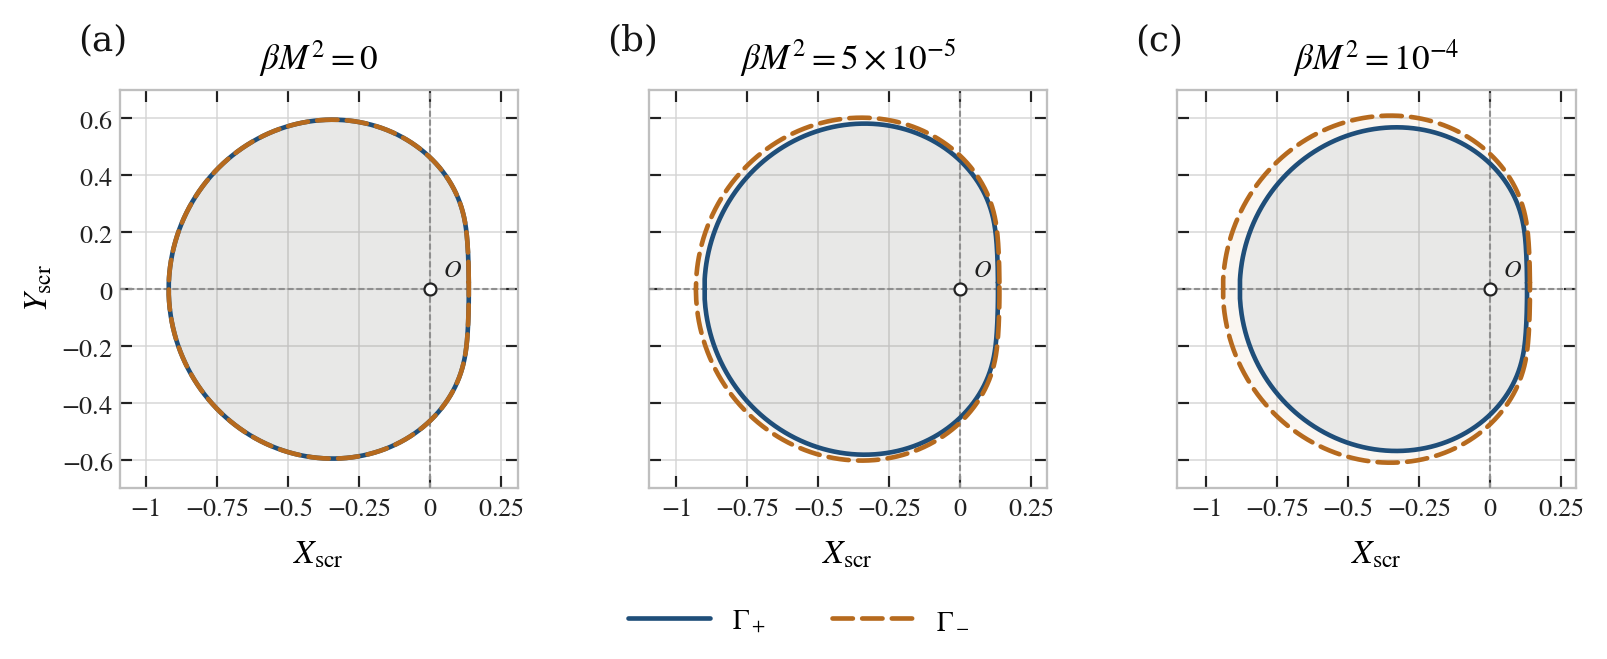

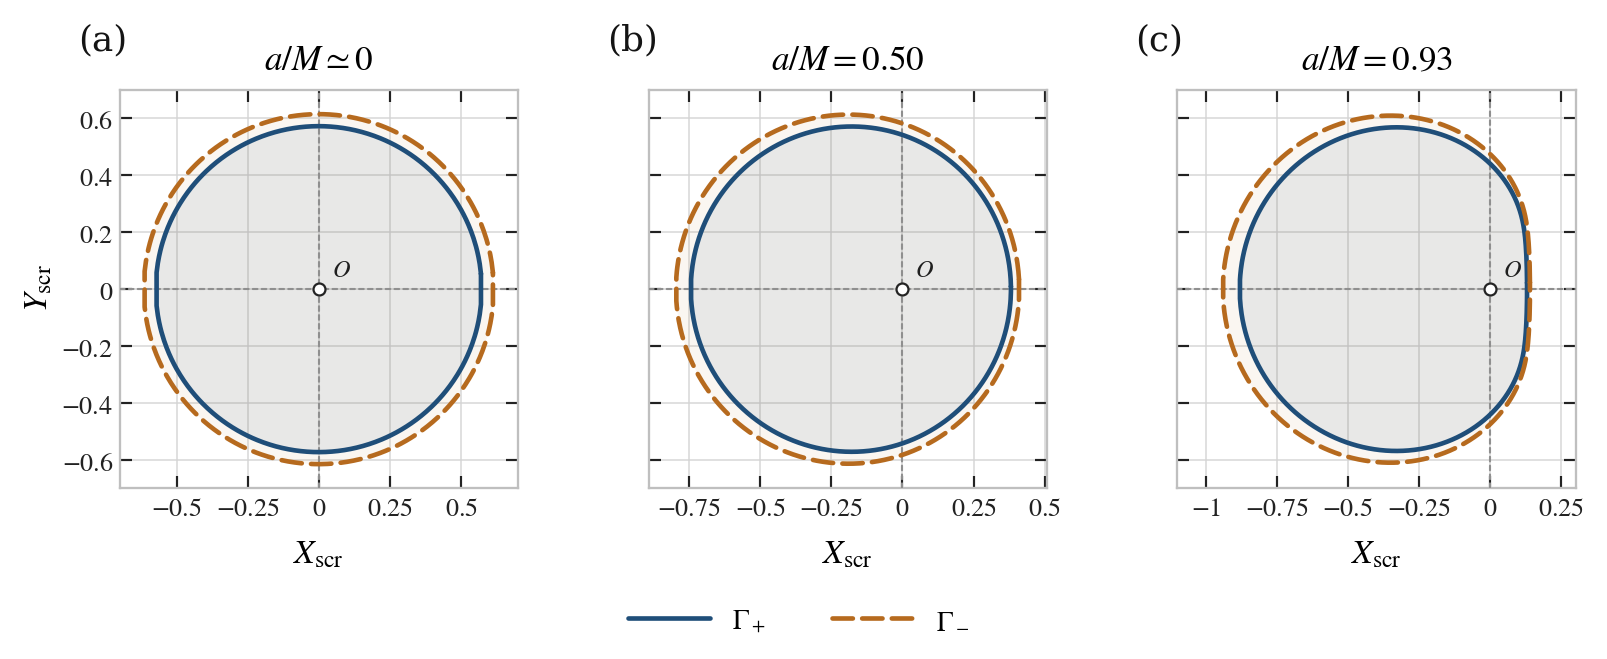

Beta figure saved to:
  PDF: outputs_GD_birefringencia/figures/figure_beta_contours_soft_filled.pdf
  PNG: outputs_GD_birefringencia/figures/figure_beta_contours_soft_filled.png

Spin figure saved to:
  PDF: outputs_GD_birefringencia/figures/figure_spin_contours_soft_filled.pdf
  PNG: outputs_GD_birefringencia/figures/figure_spin_contours_soft_filled.png


In [8]:
# ==============================================================================
#                            Figure execution
# ==============================================================================

BASE_MODEL = GDModelParams(
    M=1.0,                                                                      # Mass scale
    a=0.93,                                                                     # Base rotation
    p=0.20,                                                                     # Magnetic charge
    q=0.30,                                                                     # Electric charge
    beta=1.0e-4,                                                                # Nonlinear coupling base
    r_obs=8.0,                                                                  # Observer radius
    theta_obs_deg=85.0,                                                         # Observer inclination
)

BASE_NUM = GDNumerics(
    Nrc=4500,                                                                   # Resolution of the radial critical scan
    Nphi_static=1800,                                                           # Angular resolution of the nearly spherical case
    r_crit_max=None,                                                            # Uses the automatic radial cutoff
    horizon_root_tol=1.0e-9,                                                    # Tolerance for horizon roots
    eps_horizon=1.0e-5,                                                         # Minimum margin outside the horizon
    eps_root=1.0e-12,                                                           # Threshold for avoiding degenerate roots
    signature_tol=1.0e-11,                                                      # Margin for the regular optical domain
    static_spin_tol=1.0e-12,                                                    # Threshold for activating the exact spherical case
    small_a_threshold=5.0e-2,                                                   # Threshold for treating small spins carefully
    small_a_window_factor=20.0,                                                 # Expands the critical window when a is small
    small_a_min_window=2.0e-3,                                                  # Minimum window near the spherical limit
)

BETA_VALUES = [0.0, 5.0e-5, 1.0e-4]                                             # Scan values in βM²
SPIN_VALUES = [1.0e-3, 0.50, 0.93]                                              # Scan values in a/M


BETA_MODEL = replace(
    BASE_MODEL,
    a=0.93,                                                                     # Keeps high rotation in the β scan
    p=0.20,
    q=0.30,
    r_obs=8.0,
    theta_obs_deg=85.0,
)                                                                               # Base model for varying only β

beta_results = compute_scan(
    param_name="beta",
    values=BETA_VALUES,
    base_model=BETA_MODEL,
    num=BASE_NUM,
)                                                                               # Computes Γ+ and Γ− for each β

fig_beta_pdf, fig_beta_png = plot_contour_triptych(
    results_list=beta_results,
    values=BETA_VALUES,
    title_function=beta_panel_title,
    filename="figure_beta_contours_soft_filled",
    padding=0.12,                                                               # Visual margin around the contours
    min_half=0.70,                                                              # Minimum screen half-width
    origin_margin=0.06,                                                         # Garantiza que el origen quede visible
    round_step=0.05,                                                            # Redondea limits a escalas limpias
    axis_label_x=r"$X_{\rm scr}$",
    global_axis_label_y=r"$Y_{\rm scr}$",
)                                                                               # Generates and saves the β triptych


SPIN_MODEL = replace(
    BASE_MODEL,
    beta=1.0e-4,                                                                # Keeps the nonlinearity fixed
    p=0.20,
    q=0.30,
    r_obs=8.0,
    theta_obs_deg=85.0,
)                                                                               # Base model for varying only a/M

spin_results = compute_scan(
    param_name="a",
    values=SPIN_VALUES,
    base_model=SPIN_MODEL,
    num=BASE_NUM,
)                                                                               # Computes Γ+ and Γ− for each rotation

fig_spin_pdf, fig_spin_png = plot_contour_triptych(
    results_list=spin_results,
    values=SPIN_VALUES,
    title_function=spin_panel_title,
    filename="figure_spin_contours_soft_filled",
    padding=0.12,                                                               # Keeps the same visual margin
    min_half=0.70,                                                              # Keeps the same minimum scale
    origin_margin=0.06,                                                         # Keeps the local origin visible
    round_step=0.05,                                                            # Uses comparable clean limits
    axis_label_x=r"$X_{\rm scr}$",
    global_axis_label_y=r"$Y_{\rm scr}$",
)                                                                               # Generates and saves the a/M triptych


print("Beta figure saved to:")
print(f"  PDF: {fig_beta_pdf}")
print(f"  PNG: {fig_beta_png}")

print("\nSpin figure saved to:")
print(f"  PDF: {fig_spin_pdf}")
print(f"  PNG: {fig_spin_png}")


## **(3) Tables of geometrical observables**

We construct the tables that summarize the geometrical observables associated with the birefringent splitting of the critical contours. Three independent scans are considered,

$$10^4\beta M^2,\qquad a/M,\qquad \theta_o$$ ,

while keeping the reference configuration fixed,

$$M=1,\qquad p=0.2,\qquad q=0.3,\qquad r_o=8.$$

The numerical output is kept at two levels. The raw files preserve the values exactly as produced by the calculation, including floating-point residuals. The publication-ready version only removes residuals compatible with zero in the Maxwell limit, preventing machine-precision numerical noise from appearing as a spurious physical signal.


### **Numerical-residual control**

Before constructing the tables, we define a few numerical-hygiene routines. In particular, the angular separation is evaluated with a stable `atan2`-based form, which avoids false nonzero values when the two compared directions are nearly coincident.


In [9]:
# ==============================================================================
#                        Numerical-residual control
# ==============================================================================

RAW_ZERO_TOL = 1.0e-13                                                          # Threshold for diagnosing raw residuals
PUBLIC_ZERO_TOL = 5.0e-8                                                        # Threshold for cleaning zeros in publication-ready tables


def angular_distance_unit(u, v):
    """
    Stable angular distance between two three-dimensional unit vectors.

    The arccos(u·v) form can amplify roundoff errors when the
    vectors nearly coincide. Instead, atan2(||u×v||, u·v) uses information
    from the sine and cosine of the angle, making it more stable near zero.
    """

    u = np.asarray(u, dtype=float)                                              # Converts the first direction to a real array
    v = np.asarray(v, dtype=float)                                              # Converts the second direction to a real array

    cross_norm = np.linalg.norm(
        np.cross(u, v)
    )                                                                           # Measures the transverse part between directions

    dot = float(
        np.clip(
            np.dot(u, v),
            -1.0,
            1.0,
        )
    )                                                                           # Keeps the inner product inside the angular domain

    return float(
        np.arctan2(cross_norm, dot)
    )                                                                           # Returns the angular separation in radians


def angular_distance_2d(u, v):
    """
    Stable angular distance between two normalized directions in the plane.

    This version is used when only projected orientations
    on the screen are to be compared. The determinant represents the transverse part in 2D,
    while the inner product represents the longitudinal part.
    """

    u = np.asarray(u, dtype=float)                                              # Converts the first planar direction
    v = np.asarray(v, dtype=float)                                              # Converts the second planar direction

    det = float(
        u[0] * v[1] - u[1] * v[0]
    )                                                                           # Oriented area between both directions

    dot = float(
        np.clip(
            np.dot(u, v),
            -1.0,
            1.0,
        )
    )                                                                           # Protects the domain against roundoff

    return float(
        np.arctan2(abs(det), dot)
    )                                                                           # Returns the unoriented angle in radians


def clean_public_zero(x, tol=PUBLIC_ZERO_TOL):
    """
    Cleans numerical zeros only for the publication-ready version of the tables.

    This function does not modify the raw data. Its only goal is to prevent
    roundoff residuals compatible with zero from appearing as a separation
    physical in the Maxwell limit.
    """

    if x is None or not np.isfinite(x):
        return x                                                                # Keeps empty or nonfinite entries

    return 0.0 if abs(float(x)) < tol else float(x)                             # Cleans only residuals below tolerance


### **Global configuration**

We group into a single class the physical, geometrical, and numerical parameters used to construct the tables. This configuration fixes the base model, defines the three scans reported in the manuscript, and sets the resolution, perturbative-tolerance, and file-output controls. The idea is that the tables can be regenerated by changing only this cell, without touching the calculation routines.


In [10]:
# ==============================================================================
#                           Global configuration
# ==============================================================================

@dataclass
class Params:
    M: float = 1.0                                                              # Mass scale
    p: float = 0.2                                                              # Magnetic charge
    q: float = 0.3                                                              # Electric charge
    r_obs: float = 8.0                                                          # Observer radius
    theta_obs_deg: float = 85.0                                                 # Base observer inclination

    beta_scan_values: tuple = (0.0, 0.3, 0.5, 0.7, 1.0)                         # Scan in nonlinear coupling
    a_scan_values: tuple = (0.0, 0.3, 0.6, 0.93)                                # Rotation scan
    theta_scan_values: tuple = (17.0, 45.0, 60.0, 85.0)                         # Inclination scan

    A_STAR_OVER_M: float = 0.93                                                 # Fixed reference rotation
    BETA_STAR_M2: float = 1.0e-4                                                # Fixed reference coupling
    THETA_STAR_DEG: float = 85.0                                                # Fixed reference inclination

    EPS_MAX: float = 0.05                                                       # Maximum accepted bound for epsilon_pert

    # If True, rows with epsilon_pert > EPS_MAX are removed
    # only from the LaTeX tables. The CSV files keep all data.
    DROP_NONPERTURBATIVE_FROM_LATEX: bool = False                               # Keeps full traceability in the raw files

    alpha_plus: float = 8.0                                                     # Coefficient of the Γ+ branch
    alpha_minus: float = -4.0                                                   # Coefficient of the Γ− branch

    # Numerical controls.
    n_rc: int = 3000                                                            # Critical-radius resolution
    n_theta_eps: int = 220                                                      # Angular resolution for epsilon_pert
    n_r_eps: int = 260                                                          # Radial resolution for epsilon_pert
    n_phi_spherical: int = 1500                                                 # Angular resolution of the spherical case

    sigma_r: int = +1                                                           # Local radial ray orientation

    outdir: str = os.path.join(
        "outputs_GD_birefringencia",
        "tables",
    )                                                                           # Path where CSV and LaTeX files are saved


P = Params()                                                                    # Single configuration instance
os.makedirs(P.outdir, exist_ok=True)                                            # Creates the table folder if it does not exist


### **Background functions**

We now define the basic geometrical functions of the García--Díaz spacetime: the quadratic dyonic charge, the local observer angle, the blocks $\Sigma$ and $\Delta$, the radial derivative of $\Delta$, and the outer horizon. These functions form the common basis for computing the optical branches, the critical contours, and the geometrical observables in the tables.


In [11]:
# ==============================================================================
# Background functions
# ==============================================================================

def Q2(P=P):
    """Quadratic dyonic charge Q_c^2 = p^2 + q^2."""
    return P.p**2 + P.q**2                                                      # Background charge combination


def theta_obs(P=P):
    """Observer polar angle in radians."""
    return np.deg2rad(P.theta_obs_deg)                                          # Converts degrees to radians


def Sigma(r, theta, a):
    """Geometrical block Sigma = r^2 + a^2 cos^2(theta)."""
    return r**2 + a**2 * np.cos(theta)**2                                       # Common factor of the rotating background


def Delta(r, a, beta, P=P):
    """
    García--Díaz radial function.

    Delta(r) =
    r^2 + a^2 - 2 M r
    + (p^2+q^2) [1 - beta (r^2+a^2)]^2.
    """

    return (
        r**2
        + a**2
        - 2.0 * P.M * r
        + Q2(P) * (1.0 - beta * (r**2 + a**2))**2
    )                                                                           # Radial function fixing horizons and potentials


def Delta_prime(r, a, beta, P=P):
    """
    Radial derivative of Delta.

    If K = 1 - beta(r^2+a^2), then
    Delta' = 2r - 2M - 4 beta Q_c^2 r K.
    """

    K = 1.0 - beta * (r**2 + a**2)                                              # Radial nonlinear factor
    return (
        2.0 * r
        - 2.0 * P.M
        - 4.0 * beta * Q2(P) * r * K
    )                                                                           # Derivative used in critical conditions


def outer_horizon(a, beta, P=P):
    """
    Outer horizon of the background.

    It is obtained as the largest positive real root of Delta(r)=0.
    For nonzero beta, Delta is quartic; in the beta=0 limit,
    the same construction reduces to the Kerr--Newman quadratic polynomial.
    """

    q2 = Q2(P)                                                                  # Quadratic dyonic charge
    M = P.M                                                                     # Background mass

    c4 = q2 * beta**2                                                           # Coefficient of the r^4 term
    c3 = 0.0                                                                    # No cubic term appears
    c2 = 1.0 - 2.0 * beta * q2 + 2.0 * beta**2 * a**2 * q2
    c1 = -2.0 * M                                                               # Linear gravitational term
    c0 = a**2 + q2 * (1.0 - 2.0 * beta * a**2 + beta**2 * a**4)

    coeffs = np.array(
        [c4, c3, c2, c1, c0],
        dtype=float,
    )                                                                           # Coefficients of Delta(r)=0

    nz = np.flatnonzero(np.abs(coeffs) > 1.0e-15)                               # Locates the first nonzero coefficient

    if len(nz) == 0:
        raise RuntimeError("Degenerate Delta polynomial.")

    coeffs = coeffs[nz[0]:]                                                     # Removes leading zeros in the beta=0 limit
    roots = np.roots(coeffs)                                                    # Computes real and complex roots of the polynomial

    real_pos = sorted(
        [
            z.real
            for z in roots
            if abs(z.imag) < 1.0e-9 and z.real > 0.0
        ]
    )                                                                           # Keeps only positive real roots

    if not real_pos:
        raise RuntimeError(
            f"No positive horizon root found for a={a}, beta={beta}."
        )

    return max(real_pos)                                                        # Selects the outer horizon


### **Optical-branch functions**

We define the optical factors associated with each birefringent branch. These functions encode the separation between $\Gamma_+$ and $\Gamma_-$ through the coefficients $\alpha_s$, the optical blocks $A_s$ and $B_s$, and the local factors $\Upsilon_s$ and $\Phi_s$ evaluated on the aligned fields in the Maxwell limit.


In [12]:
# ==============================================================================
#                         Optical-branch functions
# ==============================================================================

def alpha_of(branch, P=P):
    """Returns the optical coefficient alpha_s of each branch."""

    if branch == "+":
        return P.alpha_plus                                                     # Coefficient of the Γ+ branch

    if branch == "-":
        return P.alpha_minus                                                    # Coefficient of the Γ− branch

    raise ValueError("branch must be '+' or '-'.")


def A_s(r, branch, beta, P=P):
    """Radial optical factor A_s(r) = 1 + beta alpha_s r^2."""

    return (
        1.0
        + beta * alpha_of(branch, P) * r**2
    )                                                                           # Deforms the branch radial block


def A_s_prime(r, branch, beta, P=P):
    """Radial derivative of A_s."""

    return (
        2.0 * beta * alpha_of(branch, P) * r
    )                                                                           # Enters the double-root condition


def B_s(theta, branch, a, beta, P=P):
    """Angular optical factor B_s(theta)."""

    return (
        1.0
        - beta * alpha_of(branch, P) * a**2 * np.cos(theta)**2
    )                                                                           # Deforms the branch angular block


def E0_B0(r, theta, a, P=P):
    """
    Aligned fields in the Maxwell limit.

    They are evaluated in the principal tetrad using
    x = a cos(theta), y = r and Sigma = x^2 + y^2.
    """

    x = a * np.cos(theta)                                                       # Coordenada auxiliar angular-rotating
    y = r                                                                       # Auxiliary radial coordinate
    Sig = x**2 + y**2                                                           # Sigma escrita como x^2+y^2

    Acal = (
        P.q * (x**2 - y**2)
        + 2.0 * P.p * x * y
    )                                                                           # Numerator of the aligned electric field

    Ccal = (
        P.p * (y**2 - x**2)
        + 2.0 * P.q * x * y
    )                                                                           # Numerator of the aligned magnetic field

    E0 = Acal / Sig**2                                                          # Electric field in the linear limit
    B0 = Ccal / Sig**2                                                          # Magnetic field in the linear limit

    return E0, B0


def nu_s(r, theta, a, beta, branch, P=P):
    """
    First-order Fresnel coefficient.

    Controls the local magnitude of the optical correction of each branch.
    """

    if beta == 0.0:
        return 0.0                                                              # En Maxwell no hay desdoblamiento optical

    return (
        beta
        * alpha_of(branch, P)
        * Sigma(r, theta, a)**3
        / Q2(P)
    )                                                                           # Local coefficient of branch s


def optical_factors(r, theta, a, beta, branch, P=P):
    """
    Local optical factors in the tetrad.

    Upsilon_s modifies the effective radial component.
    Phi_s modifies the effective angular components.
    """

    E0, B0 = E0_B0(r, theta, a, P)                                              # Locally evaluated Maxwell fields
    nu = nu_s(r, theta, a, beta, branch, P)                                     # Fresnel weight of the branch

    Upsilon = 1.0 + nu * E0**2                                                  # Factor associated with the electric sector
    Phi = 1.0 - nu * B0**2                                                      # Factor associated with the magnetic sector

    return Upsilon, Phi


def epsilon_pert(a, beta, P=P, r_L=None):
    """
    Perturbative control parameter.

    Measures the maximum of |nu_s E0^2| and |nu_s B0^2| in the exterior domain
    between the horizon and the cutoff radius r_L. If r_L is not specified,
    we take r_L = r_obs.
    """

    if beta == 0.0:
        return 0.0                                                              # The Maxwell limit is exactly perturbative

    if r_L is None:
        r_L = P.r_obs                                                           # Uses the observer as the natural radial cutoff

    try:
        r_plus = outer_horizon(a, beta, P)                                      # Outer horizon of the background
    except Exception:
        r_plus = 0.0                                                            # Allows continuation if the horizon diagnostic fails

    r_min = max(
        r_plus + 1.0e-5,
        1.0e-5,
    )                                                                           # Avoids evaluating on the horizon or at r=0

    r_max = max(
        r_L,
        r_min + 1.0e-3,
    )                                                                           # Guarantees a nondegenerate radial interval

    rs = np.linspace(
        r_min,
        r_max,
        P.n_r_eps,
    )                                                                           # Radial grid for the perturbative diagnostic

    ths = np.linspace(
        1.0e-5,
        np.pi - 1.0e-5,
        P.n_theta_eps,
    )                                                                           # Angular grid avoiding the poles

    maxval = 0.0                                                                # Accumulates the perturbative maximum

    for branch in ["+", "-"]:
        for r in rs:
            theta = ths                                                         # Evaluates all angles for this radius

            E0, B0 = E0_B0(r, theta, a, P)                                      # Fields on the angular grid
            nu = nu_s(r, theta, a, beta, branch, P)                             # Local coefficient of the branch

            local = np.maximum(
                np.abs(nu * E0**2),
                np.abs(nu * B0**2),
            )                                                                   # Largest local optical correction

            maxval = max(
                maxval,
                float(np.nanmax(local)),
            )                                                                   # Updates the numerical supremum

    return maxval


### **Critical constants**

We next implement the critical constants $\xi_s(r_c)$ and $k_s(r_c)$ for the rotating case. These quantities parametrize the critical family of each optical branch and are obtained by imposing the double-root condition of the effective radial potential.


In [13]:
# ==============================================================================
#                           Critical constants
# ==============================================================================

def Dfrak_s(r, a, beta, branch, P=P):
    """Radial combination appearing in the double-root condition."""

    return (
        Delta_prime(r, a, beta, P) * A_s(r, branch, beta, P)
        - Delta(r, a, beta, P) * A_s_prime(r, branch, beta, P)
    )                                                                           # D_s = Delta' A_s - Delta A_s'


def xi_k_rotating(r_c, a, beta, branch, P=P):
    """
    Critical constants for the rotating case.

    The parametrization is valid for a != 0. The spherical limit must
    be treated separately because the expressions contain divisions by a.
    """

    if abs(a) < 1.0e-12:
        raise ValueError("xi_k_rotating is singular at a=0; use spherical limit.")

    Dc = Delta(r_c, a, beta, P)                                                 # Delta evaluated at the critical radius
    As = A_s(r_c, branch, beta, P)                                              # Radial optical factor en r_c
    Ds = Dfrak_s(r_c, a, beta, branch, P)                                       # Effective double-root denominator

    if abs(Ds) < 1.0e-12 or Dc <= 0.0:
        return np.nan, np.nan                                                   # Descarta points degenerados o interiores

    xi = (
        ((r_c**2 + a**2) * Ds - 4.0 * r_c * Dc * As)
        / (a * Ds)
    )                                                                           # Axial critical parameter xi_s(r_c)

    k = (
        16.0 * r_c**2 * Dc * As**3 / Ds**2
    )                                                                           # Constante critical tipo Carter k_s(r_c)

    return xi, k


### **Local projection**


In [14]:
# ==============================================================================
#         Projection onto the local celestial sphere and screen
# ==============================================================================

def project_point_rotating(r_c, varsigma, a, beta, branch, P=P):
    """
    Projects a rotating critical point onto the local screen.

    varsigma = +1 and varsigma = -1 select the upper and
    lower halves of the contour. The function returns None if the point is not
    visible, is not real, or falls outside the admissible optical domain.
    """

    th_o = theta_obs(P)                                                         # Observer inclination
    r_o = P.r_obs                                                               # Observer radius

    xi, k = xi_k_rotating(r_c, a, beta, branch, P)                              # Critical constants of the branch

    if not np.isfinite(xi) or not np.isfinite(k) or k <= 0.0:
        return None                                                             # Requires real and admissible critical constants

    Sig_o = Sigma(r_o, th_o, a)                                                 # Sigma at the observer
    Del_o = Delta(r_o, a, beta, P)                                              # Delta at the observer

    if Del_o <= 0.0 or Sig_o <= 0.0:
        return None                                                             # Requires the observer to be in a regular exterior region

    As_o = A_s(r_o, branch, beta, P)                                            # Radial optical factor local
    Bs_o = B_s(th_o, branch, a, beta, P)                                        # Local angular optical factor

    if As_o <= 0.0 or Bs_o <= 0.0:
        return None                                                             # Requires a well-defined optical signature

    P_o = r_o**2 + a**2 - a * xi                                                # Observed radial block
    Q_o = xi - a * np.sin(th_o)**2                                              # Observed angular block

    Theta_o = k / Bs_o - Q_o**2 / np.sin(th_o)**2                               # Angular potential at the observer
    R_o = P_o**2 - (Del_o / As_o) * k                                           # Radial potential at the observer

    tol = 1.0e-12                                                               # Tolerance for small negative residuals

    if Theta_o < -tol or R_o < -tol:
        return None                                                             # The critical point does not reach the observer

    Theta_o = max(float(Theta_o), 0.0)                                          # Cleans negative roundoff residuals
    R_o = max(float(R_o), 0.0)                                                  # Cleans negative roundoff residuals

    p1 = (
        P.sigma_r * np.sqrt(R_o)
        / np.sqrt(Del_o * Sig_o)
    )                                                                           # Radial component of the covector local

    p2 = (
        varsigma * np.sqrt(Theta_o)
        / np.sqrt(Sig_o)
    )                                                                           # Polar component of the covector local

    p3 = (
        Q_o
        / (np.sqrt(Sig_o) * np.sin(th_o))
    )                                                                           # Azimuthal component of the covector local

    U, Ph = optical_factors(r_o, th_o, a, beta, branch, P)                      # Factores opticals locales

    if U <= 0.0 or Ph <= 0.0:
        return None                                                             # Discards loss of optical domain

    # Hamiltonian transport direction:
    # K_s^{hat a} = g_eff^{hat a hat b} p_hat b.
    K1 = U * p1                                                                 # Transported radial component
    K2 = Ph * p2                                                                # Transported polar component
    K3 = Ph * p3                                                                # Transported azimuthal component

    norm = np.sqrt(K1**2 + K2**2 + K3**2)                                       # Spatial norm of the transported direction

    if norm <= 0.0 or not np.isfinite(norm):
        return None                                                             # Avoids degenerate directions

    n1 = K1 / norm                                                              # Unit radial direction
    n2 = K2 / norm                                                              # Unit polar direction
    n3 = K3 / norm                                                              # Unit azimuthal direction

    # Stereographic projection onto the local screen.
    denom = 1.0 + n1                                                            # Stereographic denominator

    if abs(denom) < 1.0e-12:
        return None                                                             # Avoids the projection singularity

    X = 2.0 * n3 / denom                                                        # Horizontal screen coordinate
    Y = 2.0 * n2 / denom                                                        # Vertical screen coordinate

    if not (np.isfinite(X) and np.isfinite(Y)):
        return None                                                             # Requires finite projected coordinates

    return {
        "r_c": r_c,
        "varsigma": varsigma,
        "branch": branch,
        "xi": xi,
        "k": k,
        "n1": n1,
        "n2": n2,
        "n3": n3,
        "X": X,
        "Y": Y,
        "Theta_o": Theta_o,
        "R_o": R_o,
        "Upsilon_o": U,
        "Phi_o": Ph,
    }


def branch_curve_rotating(a, beta, branch, P=P):
    """
    Generates the projected Gamma_s curve of a rotating optical branch.

    The upper half is traversed with varsigma=+1 and increasing radius.
    The lower half is traversed with varsigma=-1 and decreasing radius.
    """

    r_plus = outer_horizon(a, beta, P)                                          # Outer horizon
    r_min = r_plus + 1.0e-5                                                     # Start of the scan outside the horizon
    r_max = P.r_obs * 0.999                                                     # Cutoff below the observer

    rows_plus = []                                                              # Upper half of the contour
    rows_minus = []                                                             # Mitad lower halves of the contour

    for r_c in np.linspace(r_min, r_max, P.n_rc):
        for varsigma, bucket in [(+1, rows_plus), (-1, rows_minus)]:
            pt = project_point_rotating(
                r_c,
                varsigma,
                a,
                beta,
                branch,
                P,
            )                                                                   # Projects a critical point of the branch

            if pt is not None:
                bucket.append(pt)                                               # Keeps only visible points

    rows_plus = sorted(
        rows_plus,
        key=lambda z: z["r_c"],
    )                                                                           # Radial order of the upper half

    rows_minus = sorted(
        rows_minus,
        key=lambda z: z["r_c"],
        reverse=True,
    )                                                                           # Reverse order to close the curve

    return rows_plus + rows_minus


def paired_curve_rotating(a, beta, P=P):
    """
    Generates paired points where both branches are visible.

    This list is used to compute separations between Γ+ and Γ−:
    Delta_cel, Delta_scr, w_br, and f_br.
    """

    r_plus = outer_horizon(a, beta, P)                                          # Outer horizon
    r_min = r_plus + 1.0e-5                                                     # Safe start of the radial scan
    r_max = P.r_obs * 0.999                                                     # Radial cutoff below the observer

    rows_top = []                                                               # Paired points from the upper half
    rows_bot = []                                                               # Paired points from the lower half

    for r_c in np.linspace(r_min, r_max, P.n_rc):
        for varsigma, bucket in [(+1, rows_top), (-1, rows_bot)]:
            pp = project_point_rotating(
                r_c,
                varsigma,
                a,
                beta,
                "+",
                P,
            )                                                                   # Γ+ point for the same r_c and varsigma

            pm = project_point_rotating(
                r_c,
                varsigma,
                a,
                beta,
                "-",
                P,
            )                                                                   # Γ− point for the same r_c and varsigma

            if pp is None or pm is None:
                continue                                                        # Compares only points visible in both branches

            n_plus = np.array(
                [pp["n1"], pp["n2"], pp["n3"]],
                dtype=float,
            )                                                                   # Celestial direction of Γ+

            n_minus = np.array(
                [pm["n1"], pm["n2"], pm["n3"]],
                dtype=float,
            )                                                                   # Celestial direction of Γ−

            X_plus = np.array(
                [pp["X"], pp["Y"]],
                dtype=float,
            )                                                                   # Screen point of Γ+

            X_minus = np.array(
                [pm["X"], pm["Y"]],
                dtype=float,
            )                                                                   # Screen point of Γ−

            Delta_cel = angular_distance_unit(
                n_plus,
                n_minus,
            )                                                                   # Angular separation on the celestial sphere

            Delta_scr = float(
                np.linalg.norm(X_plus - X_minus)
            )                                                                   # Euclidean separation on the screen

            bucket.append({
                "r_c": r_c,
                "varsigma": varsigma,
                "n_plus": n_plus,
                "n_minus": n_minus,
                "X_plus": X_plus,
                "X_minus": X_minus,
                "Delta_cel": Delta_cel,
                "Delta_scr": Delta_scr,
            })                                                                  # Stores the comparable geometrical pair

    rows_top = sorted(
        rows_top,
        key=lambda z: z["r_c"],
    )                                                                           # Radial order of the upper half

    rows_bot = sorted(
        rows_bot,
        key=lambda z: z["r_c"],
        reverse=True,
    )                                                                           # Reverse order of the lower half

    return rows_top + rows_bot


### **Spherical limit**

We treat the case $(a=0)$ separately, because the rotating critical constants contain divisions by $(a)$ and must not be evaluated directly in the spherical limit. In this regime, the projected contours are concentric circles, and the observables can be computed from the critical radius, the effective impact parameter, and the screen radius of each optical branch.


In [15]:
# ==============================================================================
#                         Spherical limit a = 0
# ==============================================================================

def b2_spherical(r, beta, branch, P=P):
    """
    Squared critical impact parameter in the spherical limit.
    """

    return (
        r**4
        * A_s(r, branch, beta, P)
        / Delta(r, 0.0, beta, P)
    )                                                                           # b_s^2 = r^4 A_s / Delta


def critical_radius_spherical(beta, branch, P=P):
    """
    Spherical critical radius of an optical branch.

    It is obtained by extremizing b_s^2(r), which is equivalent to solving
    4/r + A_s'/A_s - Delta'/Delta = 0.
    """

    a = 0.0                                                                     # Nonrotating limit
    r_plus = outer_horizon(a, beta, P)                                          # Outer horizon spherical
    r_min = r_plus + 1.0e-5                                                     # Safe start outside the horizon
    r_max = P.r_obs * 0.999                                                     # Radial cutoff below the observer

    def F(r):
        return (
            4.0 / r
            + A_s_prime(r, branch, beta, P) / A_s(r, branch, beta, P)
            - Delta_prime(r, a, beta, P) / Delta(r, a, beta, P)
        )                                                                       # Critical equation d(b_s^2)/dr = 0

    grid = np.linspace(r_min, r_max, 2500)                                      # Grid for detecting sign changes
    vals = np.array([F(x) for x in grid])                                       # Evaluates the critical condition

    roots = []                                                                  # Stores refined roots

    for i in range(len(grid) - 1):
        if not np.isfinite(vals[i]) or not np.isfinite(vals[i + 1]):
            continue                                                            # Skips ill-defined intervals

        if vals[i] == 0.0:
            roots.append(grid[i])                                               # Exceptional case: exact root on the grid

        elif vals[i] * vals[i + 1] < 0.0:
            try:
                roots.append(
                    brentq(F, grid[i], grid[i + 1], maxiter=200)
                )                                                               # Refines the root inside the interval
            except ValueError:
                pass                                                            # Ignores numerically problematic intervals

    if not roots:
        raise RuntimeError(
            f"No spherical critical radius found for beta={beta}, branch={branch}."
        )

    return max(roots)                                                           # Selects the exterior critical root


def spherical_screen_radius(beta, branch, P=P):
    """
    Screen radius of an optical branch in the spherical limit.

    Returns:
        r_ph            critical radius,
        b2              squared impact parameter,
        screen_radius   stereographic screen radius,
        n1              local radial component,
        n_perp          local transverse component.
    """

    a = 0.0                                                                     # Spherical limit
    r_o = P.r_obs                                                               # Observer radius
    th_o = theta_obs(P)                                                         # Observer inclination

    r_ph = critical_radius_spherical(beta, branch, P)                           # Critical radius of the branch
    b2 = b2_spherical(r_ph, beta, branch, P)                                    # Impacto critical al cuadrado

    Del_o = Delta(r_o, a, beta, P)                                              # Delta at the observer
    As_o = A_s(r_o, branch, beta, P)                                            # Radial optical factor local

    R_o = r_o**4 - (Del_o / As_o) * b2                                          # Observed radial potential

    if R_o < 0.0:
        raise RuntimeError("Spherical branch is not visible at observer.")

    p1 = (
        P.sigma_r
        * np.sqrt(max(R_o, 0.0))
        / (np.sqrt(Del_o) * r_o)
    )                                                                           # Local radial component

    p_perp = np.sqrt(b2) / r_o                                                  # Local transverse component

    U, Ph = optical_factors(r_o, th_o, a, beta, branch, P)                      # Factores opticals locales

    K1 = U * p1                                                                 # Transported radial direction
    Kp = Ph * p_perp                                                            # Transported transverse direction

    norm = np.sqrt(K1**2 + Kp**2)                                               # Norma local bidimensional

    n1 = K1 / norm                                                              # Unit radial component
    n_perp = Kp / norm                                                          # Unit transverse component

    screen_radius = 2.0 * n_perp / (1.0 + n1)                                   # Stereographic radius of the circle

    return r_ph, b2, screen_radius, n1, n_perp


def observables_spherical(beta, scan_label, scan_key, scan_value, P=P):
    """
    Geometrical observables in the spherical limit a = 0.
    """

    rph_p, b2p, Rp, n1p, nperpp = spherical_screen_radius(beta, "+", P)
    rph_m, b2m, Rm, n1m, nperpm = spherical_screen_radius(beta, "-", P)

    u_plus = np.array([n1p, nperpp], dtype=float)                               # Local direction of Γ+
    u_minus = np.array([n1m, nperpm], dtype=float)                              # Local direction of Γ−

    Delta_cel = angular_distance_2d(u_plus, u_minus)                            # Angular separation between circles
    Delta_scr = abs(Rp - Rm)                                                    # Radial separation on screen

    d_plus = 2.0 * Rp                                                           # Effective diameter of Γ+
    d_minus = 2.0 * Rm                                                          # Effective diameter of Γ−
    d0 = 0.5 * (d_plus + d_minus)                                               # Mean reference diameter

    delta_d = (
        2.0 * abs(d_plus - d_minus) / (d_plus + d_minus)
    )                                                                           # Fractional diameter difference

    # For concentric circles:
    # delta X_perp = Rp - Rm and w_br = |Rp - Rm|/2.
    w_br = 0.5 * abs(Rp - Rm)                                                   # Ancho birefringent efectivo
    f_br = w_br / d0 if d0 > 0.0 else np.nan                                    # Relative width fraction

    eps = epsilon_pert(0.0, beta, P, r_L=P.r_obs)                               # Perturbative control for the case

    return {
        "scan": scan_label,
        "scan_key": scan_key,
        "scan_value": scan_value,
        "a": 0.0,
        "a_over_M": 0.0,
        "betaM2": beta * P.M**2,
        "beta_display_1e4": 1.0e4 * beta * P.M**2,
        "theta_obs_deg": P.theta_obs_deg,
        "epsilon_pert": eps,
        "epsilon_ok": eps <= P.EPS_MAX,
        "Delta_cel_max": Delta_cel,
        "Delta_cel_mean": Delta_cel,
        "Delta_scr_max": Delta_scr,
        "Delta_scr_mean": Delta_scr,
        "d_plus": d_plus,
        "d_minus": d_minus,
        "d0": d0,
        "delta_d_br": delta_d,
        "w_br": w_br,
        "f_br": f_br,
        "N_plus": P.n_phi_spherical,
        "N_minus": P.n_phi_spherical,
        "N_br": P.n_phi_spherical,
        "r_plus": outer_horizon(0.0, beta, P),
        "rcrit_min": min(rph_p, rph_m),
        "rcrit_max": max(rph_p, rph_m),
        "note": "OK" if eps <= P.EPS_MAX else "epsilon > cutoff",
    }


### **Discrete geometry of the contours**

For rotating cases, the contours $\Gamma_+$ and $\Gamma_-$ are represented as discrete curves on the local screen. From these curves we compute lengths, geometrical centers, effective diameters, and the birefringent width associated with the normal separation between both branches.


In [16]:
# ==============================================================================
#                   Discrete geometry of the contours
# ==============================================================================

def points_from_curve(curve):
    """Extracts the screen points as an Nx2 array."""

    if len(curve) == 0:
        return np.empty((0, 2))                                                 # Empty curve

    return np.array(
        [[row["X"], row["Y"]] for row in curve],
        dtype=float,
    )                                                                           # Projected screen points


def closed_segments(points):
    """
    Segments of a discrete closed curve.

    Returns segment vectors, lengths, and midpoints.
    """

    if len(points) < 3:
        return None, None, None                                                 # No useful closed polygon

    nxt = np.roll(points, -1, axis=0)                                           # Next point, with periodic closure
    seg = nxt - points                                                          # Vectors of each segment
    dl = np.linalg.norm(seg, axis=1)                                            # Discrete arc lengths
    mid = 0.5 * (points + nxt)                                                  # Segment midpoints

    good = dl > 1.0e-14                                                         # Descarta segmentos degenerados

    return seg[good], dl[good], mid[good]


def effective_diameter(points):
    """
    Effective diameter of a closed contour.

    It is computed from the total length, the center weighted by
    arc length and the mean radius relative to that center.
    """

    seg, dl, mid = closed_segments(points)

    if seg is None or len(dl) == 0:
        return np.nan, np.nan, np.array([np.nan, np.nan])

    L = float(np.sum(dl))                                                       # Total contour length
    C = np.sum(mid * dl[:, None], axis=0) / L                                   # Centro ponderado por longitud

    Rbar = float(
        np.sum(np.linalg.norm(mid - C, axis=1) * dl) / L
    )                                                                           # Radio medio efectivo

    d = 2.0 * Rbar                                                              # Effective diameter

    return d, L, C


def birefringent_width(paired_rows):
    """
    Discrete birefringent width.

    It is computed by projecting the separation between Γ+ and Γ− onto the normal
    local to the mean contour.
    """

    if len(paired_rows) < 3:
        return np.nan, np.nan                                                   # There are not enough visible pairs

    Xp = np.array([row["X_plus"] for row in paired_rows], dtype=float)
    Xm = np.array([row["X_minus"] for row in paired_rows], dtype=float)

    Xbar = 0.5 * (Xp + Xm)                                                      # Mean contour
    dX = Xp - Xm                                                                # Separation between branches

    Xbar_next = np.roll(Xbar, -1, axis=0)                                       # Next point of the mean contour
    dX_next = np.roll(dX, -1, axis=0)                                           # Next separation between branches

    seg = Xbar_next - Xbar                                                      # Segments of the mean contour
    dl = np.linalg.norm(seg, axis=1)                                            # Longitudes discretas

    good = dl > 1.0e-14                                                         # Descarta segmentos degenerados

    if not np.any(good):
        return np.nan, np.nan

    seg = seg[good]
    dl = dl[good]

    dX_mid = 0.5 * (dX[good] + dX_next[good])                                   # Separation evaluated at midpoints

    t_hat = seg / dl[:, None]                                                   # Unit tangent to the mean contour

    # Normal in the screen plane: m_hat = (-t_y, t_x).
    m_hat = np.column_stack((-t_hat[:, 1], t_hat[:, 0]))

    delta_perp = np.sum(dX_mid * m_hat, axis=1)                                 # Normal separation between branches

    Lbar = float(np.sum(dl))                                                    # Length of the mean contour

    w2 = float(
        np.sum((delta_perp**2) * dl) / (4.0 * Lbar)
    )                                                                           # Normal quadratic mean

    return np.sqrt(max(w2, 0.0)), Lbar


### **Observable calculation**

We finally assemble the geometrical observables used in the tables: maximum and mean angular separation, screen separation, effective diameters, fractional diameter difference, birefringent width, and relative fraction $f_{\rm br}$. This cell also organizes the three scans reported in the manuscript and separates the raw output from the cleaned publication-ready version.


In [17]:
# ==============================================================================
#                         Observable calculation
# ==============================================================================

def observables_rotating(a, beta, scan_label, scan_key, scan_value, P=P):
    """
    Computes all geometrical observables for a rotating case.
    """

    curve_p = branch_curve_rotating(a, beta, "+", P)                            # Contour Γ+
    curve_m = branch_curve_rotating(a, beta, "-", P)                            # Contour Γ−
    paired = paired_curve_rotating(a, beta, P)                                  # Points visible in both branches

    pts_p = points_from_curve(curve_p)                                          # Screen points of Γ+
    pts_m = points_from_curve(curve_m)                                          # Screen points of Γ−

    d_plus, L_plus, C_plus = effective_diameter(pts_p)
    d_minus, L_minus, C_minus = effective_diameter(pts_m)

    d0 = 0.5 * (d_plus + d_minus)                                               # Mean reference diameter

    if d_plus + d_minus > 0.0:
        delta_d = (
            2.0 * abs(d_plus - d_minus) / (d_plus + d_minus)
        )                                                                       # Fractional diameter difference
    else:
        delta_d = np.nan

    if paired:
        Delta_cel_vals = np.array([row["Delta_cel"] for row in paired])
        Delta_scr_vals = np.array([row["Delta_scr"] for row in paired])

        Delta_cel_max = float(np.nanmax(Delta_cel_vals))
        Delta_cel_mean = float(np.nanmean(Delta_cel_vals))

        Delta_scr_max = float(np.nanmax(Delta_scr_vals))
        Delta_scr_mean = float(np.nanmean(Delta_scr_vals))

    else:
        Delta_cel_max = np.nan
        Delta_cel_mean = np.nan
        Delta_scr_max = np.nan
        Delta_scr_mean = np.nan

    w_br, Lbar = birefringent_width(paired)                                     # Global birefringent width

    f_br = (
        w_br / d0
        if d0 and np.isfinite(d0) and d0 > 0.0
        else np.nan
    )                                                                           # Width relative to the mean diameter

    eps = epsilon_pert(a, beta, P, r_L=P.r_obs)                                 # Perturbative-validity diagnostic

    rcs = [row["r_c"] for row in paired]                                        # Visible paired critical radii

    return {
        "scan": scan_label,
        "scan_key": scan_key,
        "scan_value": scan_value,
        "a": a,
        "a_over_M": a / P.M,
        "betaM2": beta * P.M**2,
        "beta_display_1e4": 1.0e4 * beta * P.M**2,
        "theta_obs_deg": P.theta_obs_deg,
        "epsilon_pert": eps,
        "epsilon_ok": eps <= P.EPS_MAX,
        "Delta_cel_max": Delta_cel_max,
        "Delta_cel_mean": Delta_cel_mean,
        "Delta_scr_max": Delta_scr_max,
        "Delta_scr_mean": Delta_scr_mean,
        "d_plus": d_plus,
        "d_minus": d_minus,
        "d0": d0,
        "delta_d_br": delta_d,
        "w_br": w_br,
        "f_br": f_br,
        "N_plus": len(curve_p),
        "N_minus": len(curve_m),
        "N_br": len(paired),
        "r_plus": outer_horizon(a, beta, P),
        "rcrit_min": float(np.nanmin(rcs)) if rcs else np.nan,
        "rcrit_max": float(np.nanmax(rcs)) if rcs else np.nan,
        "note": "OK" if eps <= P.EPS_MAX else "epsilon > cutoff",
    }


def compute_one_case(a, beta, scan_label, scan_key, scan_value, P=P):
    """
    Automatically selects between the spherical and rotating case.
    """

    if abs(a) < 1.0e-12:
        return observables_spherical(
            beta,
            scan_label,
            scan_key,
            scan_value,
            P,
        )                                                                       # Uses the exact spherical reduction

    return observables_rotating(
        a,
        beta,
        scan_label,
        scan_key,
        scan_value,
        P,
    )                                                                           # Uses the rotating construction


def prepare_table_dataframe(df, clean_for_publication=True):
    """
    Prepares compact columns for the tables.

    If clean_for_publication=True, only residuals compatible
    with zero in exact limits are cleaned. Raw data must be saved with
    clean_for_publication=False.
    """

    df = df.copy()                                                              # Avoids modifying the input table

    biref_cols = [
        "Delta_cel_max",
        "Delta_cel_mean",
        "Delta_scr_max",
        "Delta_scr_mean",
        "delta_d_br",
        "w_br",
        "f_br",
    ]                                                                           # Columnas que deben anularse en Maxwell

    if clean_for_publication:
        for col in biref_cols:
            if col in df.columns:
                df[col] = df[col].map(clean_public_zero)                        # Presentation-residual cleaning

        # Exact check of the Maxwell limit in the publication layer.
        if "betaM2" in df.columns:
            maxwell_mask = np.isclose(
                df["betaM2"],
                0.0,
                atol=1.0e-16,
            )                                                                   # Rows of the exact linear limit

            for col in biref_cols:
                if col in df.columns:
                    df.loc[maxwell_mask, col] = 0.0                             # Fuerza splitting nulo en Maxwell

            # In Maxwell theory the two optical branches coincide.
            if {"d_plus", "d_minus", "d0"}.issubset(df.columns):
                dbar = 0.5 * (
                    df.loc[maxwell_mask, "d_plus"]
                    + df.loc[maxwell_mask, "d_minus"]
                )

                df.loc[maxwell_mask, "d_plus"] = dbar
                df.loc[maxwell_mask, "d_minus"] = dbar
                df.loc[maxwell_mask, "d0"] = dbar

    df["1e4_Delta_cel_max"] = 1.0e4 * df["Delta_cel_max"]
    df["1e4_Delta_cel_mean"] = 1.0e4 * df["Delta_cel_mean"]
    df["100_delta_d_br"] = 100.0 * df["delta_d_br"]
    df["100_f_br"] = 100.0 * df["f_br"]

    return df


def build_all_tables(P=P):
    """
    Builds the three table scans:

      1) beta scan with fixed a and theta_o,
      2) a/M scan with fixed beta and theta_o,
      3) theta_o scan with fixed a and beta.
    """

    rows = []                                                                   # Accumulates all raw rows

    # --------------------------------------------------------------------------
    # Scan 1: variation of beta.
    # La variable mostrada es 10^4 beta M^2.
    # --------------------------------------------------------------------------
    for beta_display in P.beta_scan_values:
        beta = beta_display * 1.0e-4 / P.M**2                                   # Converts the displayed scale to beta
        a = P.A_STAR_OVER_M * P.M                                               # Keeps the rotation fixed
        P_case = replace(P, theta_obs_deg=P.THETA_STAR_DEG)

        rows.append(
            compute_one_case(
                a=a,
                beta=beta,
                scan_label=r"$10^4\beta M^2$-scan",
                scan_key="beta",
                scan_value=beta_display,
                P=P_case,
            )
        )

    # --------------------------------------------------------------------------
    # Scan 2: variation of spin.
    # La variable mostrada es a/M.
    # --------------------------------------------------------------------------
    for a_over_M in P.a_scan_values:
        beta = P.BETA_STAR_M2 / P.M**2                                          # Keeps beta M^2 fixed
        a = a_over_M * P.M                                                      # Convierte a/M en a
        P_case = replace(P, theta_obs_deg=P.THETA_STAR_DEG)

        rows.append(
            compute_one_case(
                a=a,
                beta=beta,
                scan_label=r"$a/M$-scan",
                scan_key="spin",
                scan_value=a_over_M,
                P=P_case,
            )
        )

    # --------------------------------------------------------------------------
    # Scan 3: variation of the observer inclination.
    # La variable mostrada es theta_o en grados.
    # --------------------------------------------------------------------------
    for theta_deg in P.theta_scan_values:
        beta = P.BETA_STAR_M2 / P.M**2                                          # Keeps beta M^2 fixed
        a = P.A_STAR_OVER_M * P.M                                               # Keeps the rotation fixed
        P_case = replace(P, theta_obs_deg=theta_deg)

        rows.append(
            compute_one_case(
                a=a,
                beta=beta,
                scan_label=r"$\theta_o$-scan",
                scan_key="inclination",
                scan_value=theta_deg,
                P=P_case,
            )
        )

    raw_full = pd.DataFrame(rows)                                               # Raw table of all scans
    raw_full = prepare_table_dataframe(
        raw_full,
        clean_for_publication=False,
    )                                                                           # Preserves raw numerical residuals

    public_full = prepare_table_dataframe(
        raw_full,
        clean_for_publication=True,
    )                                                                           # Cleans only the publication layer

    latex_full = public_full.copy()                                             # Base for LaTeX tables

    if P.DROP_NONPERTURBATIVE_FROM_LATEX:
        latex_full = latex_full[latex_full["epsilon_ok"]].copy()                # Filtro opcional por validez

    beta_df = latex_full[latex_full["scan_key"] == "beta"].copy()
    spin_df = latex_full[latex_full["scan_key"] == "spin"].copy()
    theta_df = latex_full[latex_full["scan_key"] == "inclination"].copy()

    return raw_full, public_full, beta_df, spin_df, theta_df


### **LaTeX export**

At this stage we prepare the final table outputs. First, formatting functions are defined to write numbers compatible with `siunitx` S columns; then the headers, titles, captions, and labels of each scan are built. Finally, the complete CSV files and LaTeX tables are exported in a `REVTeX`-compatible format, using `ruledtabular` to keep the presentation compact and consistent with the manuscript.


In [18]:
# ==============================================================================
#                           LaTeX export
# ==============================================================================

def tex_plain(x, digits=4):
    """
    Converts a number to a decimal string for siunitx S columns.

    Missing or nonfinite values are protected as LaTeX text.
    """

    if x is None or not np.isfinite(x):
        return r"{\cdots}"                                                      # Protected entry for numerical columns

    return f"{float(x):.{digits}f}"                                             # Fixed-precision decimal


def tex_int(x):
    """
    Converts a numerical value to an integer for siunitx S columns.
    """

    if x is None or not np.isfinite(x):
        return r"{\cdots}"                                                      # Protected entry for missing values

    return str(int(round(float(x))))                                            # Rounded integer for counts


def table_preamble():
    """
    LaTeX preamble fragment for the tables.

    It should be included once if the manuscript does not yet configure siunitx.
    REVTeX provides the ruledtabular environment.
    """

    return r"""
% Required in the preamble:
% \usepackage{siunitx}
% REVTeX supplies ruledtabular.
\sisetup{
  detect-all,
  table-number-alignment = center,
  round-mode = places,
  round-pad = true,
  output-decimal-marker = {.}
}
\newcommand{\tabhead}[1]{\multicolumn{1}{c}{\(#1\)}}
""".strip()


def caption_for_scan(scan_key, P=P):
    """
    Builds the caption of each table.

    The caption concentrates the common conditions and avoids repeating
    epsilon_pert row by row.
    """

    common = (
        r"We fix \(M=" + f"{P.M:g}" + r"\), "
        r"\(p=" + f"{P.p:g}" + r"\), "
        r"\(q=" + f"{P.q:g}" + r"\) and "
        r"\(r_o=" + f"{P.r_obs:g}" + r"\). "
        r"\(\epsilon_{\rm pert}\) is not shown row by row to avoid "
        r"redundancy; the criterion used to accept the optical regime is "
        r"\(\epsilon_{\rm pert}\le " + f"{P.EPS_MAX:.2f}" + r"\), "
        r"and its full values are kept in the CSV file. "
        r"The columns \(\Delta_{\max}\), "
        r"\(\langle\Delta_{\rm cel}\rangle\), "
        r"\(\delta d_{\rm br}\) and \(f_{\rm br}\) are reported as "
        r"\(10^4\Delta_{\max}\), "
        r"\(10^4\langle\Delta_{\rm cel}\rangle\), "
        r"\(10^2\delta d_{\rm br}\) and "
        r"\(10^2 f_{\rm br}\), respectively."
    )                                                                           # Common conditions for the three tables

    if scan_key == "beta":
        lead = (
            r"Scan in the nonlinear coupling \(\beta\) for the "
            r"critical contours \(\Gamma_+\) and \(\Gamma_-\). "
            r"We fix \(a/M=" + f"{P.A_STAR_OVER_M:g}" + r"\) and "
            r"\(\theta_o=" + f"{P.THETA_STAR_DEG:g}" + r"^\circ\). "
        )                                                                       # Description of the beta scan

    elif scan_key == "spin":
        lead = (
            r"Rotation scan for the critical contours "
            r"\(\Gamma_+\) and \(\Gamma_-\). "
            r"We fix \(\beta M^2=10^{-4}\) and "
            r"\(\theta_o=" + f"{P.THETA_STAR_DEG:g}" + r"^\circ\). "
        )                                                                       # Description of the a/M scan

    elif scan_key == "inclination":
        lead = (
            r"Observer-inclination scan for the critical contours "
            r"\(\Gamma_+\) and \(\Gamma_-\). "
            r"We fix \(a/M=" + f"{P.A_STAR_OVER_M:g}" + r"\) and "
            r"\(\beta M^2=10^{-4}\). "
        )                                                                       # Description of the theta_o scan

    else:
        lead = r"Birefringent geometrical observables. "

    return lead + common


def scan_table_label(scan_key):
    """
    LaTeX label for each table.
    """

    return {
        "beta": "tab:prd_beta_scan_observables",
        "spin": "tab:prd_spin_scan_observables",
        "inclination": "tab:prd_inclination_scan_observables",
    }[scan_key]


def scan_table_title(scan_key):
    """
    Title of the first column according to the scanned parameter.
    """

    return {
        "beta": r"10^4\beta M^2",
        "spin": r"a/M",
        "inclination": r"\theta_o({}^{\circ})",
    }[scan_key]


def write_scan_latex(df, path, scan_key, P=P):
    """
    Writes a compact REVTeX/PRD table.

    The table includes the main geometrical observables and some
    auxiliary diagnostics. epsilon_pert no aparece row by row porque
    it is documented in the caption and fully preserved in the CSV files.
    """

    lines = []                                                                  # Accumulates lines of the .tex file

    lines.append(r"\begin{table*}[t]")                                          # Wide two-column table
    lines.append(r"\centering")
    lines.append(r"\caption{")
    lines.append(caption_for_scan(scan_key, P))                                 # Scan-specific caption
    lines.append(r"}")
    lines.append(r"\label{" + scan_table_label(scan_key) + r"}")
    lines.append(r"\begingroup")
    lines.append(r"\scriptsize")                                                # Compact size for many columns
    lines.append(r"\setlength{\tabcolsep}{2.0pt}")                              # Reduces horizontal spacing
    lines.append(r"\renewcommand{\arraystretch}{1.08}")                         # Moderate vertical adjustment
    lines.append(r"\begin{ruledtabular}")                                       # REVTeX ruled style
    lines.append(r"\begin{tabular}{")
    lines.append(r"S[table-format=3.2]")                                        # Scan variable
    lines.append(r"S[table-format=1.5]")                                        # r_+
    lines.append(r"S[table-format=1.5]")                                        # r_c min
    lines.append(r"S[table-format=1.5]")                                        # r_c max
    lines.append(r"S[table-format=4.3]")                                        # 10^4 Delta max
    lines.append(r"S[table-format=4.3]")                                        # 10^4 Delta mean
    lines.append(r"S[table-format=1.5]")                                        # Delta_scr max
    lines.append(r"S[table-format=1.5]")                                        # Delta_scr mean
    lines.append(r"S[table-format=1.5]")                                        # d_+
    lines.append(r"S[table-format=1.5]")                                        # d_-
    lines.append(r"S[table-format=1.5]")                                        # d_0
    lines.append(r"S[table-format=2.4]")                                        # 10^2 delta d_br
    lines.append(r"S[table-format=1.5]")                                        # w_br
    lines.append(r"S[table-format=2.4]")                                        # 10^2 f_br
    lines.append(r"S[table-format=4.0]")                                        # N_br
    lines.append(r"}")
    lines.append(r"\tabhead{" + scan_table_title(scan_key) + r"} &")
    lines.append(r"\tabhead{r_+} &")
    lines.append(r"\tabhead{r_c^{\rm min}} &")
    lines.append(r"\tabhead{r_c^{\rm max}} &")
    lines.append(r"\tabhead{10^4\Delta_{\max}} &")
    lines.append(r"\tabhead{10^4\langle\Delta_{\rm cel}\rangle} &")
    lines.append(r"\tabhead{\Delta_{\rm scr}^{\max}} &")
    lines.append(r"\tabhead{\langle\Delta_{\rm scr}\rangle} &")
    lines.append(r"\tabhead{d_+} &")
    lines.append(r"\tabhead{d_-} &")
    lines.append(r"\tabhead{d_0} &")
    lines.append(r"\tabhead{10^2\delta d_{\rm br}} &")
    lines.append(r"\tabhead{w_{\rm br}} &")
    lines.append(r"\tabhead{10^2 f_{\rm br}} &")
    lines.append(r"\tabhead{N_{\rm br}} \\")
    lines.append(r"\hline")

    for _, row in df.iterrows():
        if scan_key == "inclination":
            scan_digits = 0                                                     # theta_o is shown as an integer
        else:
            scan_digits = 2                                                     # beta-display and a/M use two decimals

        vals = [
            tex_plain(row["scan_value"], scan_digits),
            tex_plain(row["r_plus"], 5),
            tex_plain(row["rcrit_min"], 5),
            tex_plain(row["rcrit_max"], 5),
            tex_plain(row["1e4_Delta_cel_max"], 3),
            tex_plain(row["1e4_Delta_cel_mean"], 3),
            tex_plain(row["Delta_scr_max"], 5),
            tex_plain(row["Delta_scr_mean"], 5),
            tex_plain(row["d_plus"], 5),
            tex_plain(row["d_minus"], 5),
            tex_plain(row["d0"], 5),
            tex_plain(row["100_delta_d_br"], 4),
            tex_plain(row["w_br"], 5),
            tex_plain(row["100_f_br"], 4),
            tex_int(row["N_br"]),
        ]                                                                       # Values of a row in column order

        lines.append(" & ".join(vals) + r" \\")                                 # Complete LaTeX row

    lines.append(r"\end{tabular}")
    lines.append(r"\end{ruledtabular}")
    lines.append(r"\endgroup")
    lines.append(r"\end{table*}")

    with open(path, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))                                               # Writes the individual table


def write_all_tables_file(paths, outpath):
    """
    Concatenates the siunitx configuretion and the three LaTeX tables.
    """

    chunks = [table_preamble(), ""]                                             # Includes common preamble

    for p in paths:
        with open(p, "r", encoding="utf-8") as f:
            chunks.append(f.read())                                             # Adds each table
        chunks.append("\n")

    with open(outpath, "w", encoding="utf-8") as f:
        f.write("\n".join(chunks))                                              # Writes the combined file


def save_outputs(raw_full_df, public_full_df, beta_df, spin_df, theta_df, P=P):
    """
    Saves CSV and LaTeX outputs.

    Two global CSV files are generated:
      - full_observables_all_scans_raw.csv preserves the raw values.
      - full_observables_all_scans_public.csv applies presentation cleaning.

    In addition, CSV files and LaTeX tables are written for each scan.
    """

    os.makedirs(P.outdir, exist_ok=True)                                        # Ensures the output folder

    # Machine-readable outputs.
    raw_full_path = os.path.join(P.outdir, "full_observables_all_scans_raw.csv")
    public_full_path = os.path.join(P.outdir, "full_observables_all_scans_public.csv")
    beta_csv = os.path.join(P.outdir, "beta_scan_observables.csv")
    spin_csv = os.path.join(P.outdir, "spin_scan_observables.csv")
    theta_csv = os.path.join(P.outdir, "inclination_scan_observables.csv")

    raw_full_df.to_csv(raw_full_path, index=False)                              # Complete table without visual cleaning
    public_full_df.to_csv(public_full_path, index=False)                        # Complete table ready for reading
    beta_df.to_csv(beta_csv, index=False)                                       # Beta scan
    spin_df.to_csv(spin_csv, index=False)                                       # Scan in a/M
    theta_df.to_csv(theta_csv, index=False)                                     # Scan in theta_o

    # LaTeX tables ready for the manuscript.
    beta_tex = os.path.join(P.outdir, "table_beta_scan.tex")
    spin_tex = os.path.join(P.outdir, "table_spin_scan.tex")
    theta_tex = os.path.join(P.outdir, "table_inclination_scan.tex")

    write_scan_latex(beta_df, beta_tex, "beta", P)                              # LaTeX table for the beta scan
    write_scan_latex(spin_df, spin_tex, "spin", P)                              # LaTeX table for the a/M scan
    write_scan_latex(theta_df, theta_tex, "inclination", P)                     # LaTeX table for the angular scan

    all_tex = os.path.join(P.outdir, "tables_all.tex")
    write_all_tables_file(
        [beta_tex, spin_tex, theta_tex],
        all_tex,
    )                                                                           # Single file with the three tables

    return {
        "raw_full_csv": raw_full_path,
        "public_full_csv": public_full_path,
        "beta_csv": beta_csv,
        "spin_csv": spin_csv,
        "theta_csv": theta_csv,
        "beta_tex": beta_tex,
        "spin_tex": spin_tex,
        "theta_tex": theta_tex,
        "all_tex": all_tex,
    }                                                                           # Record of all outputs


### **Table execution**

This cell builds the three tables of geometrical observables and writes the outputs to disk. The displayed table corresponds to the publication-ready version, where only residuals compatible with zero in exact limits are cleaned. The raw CSV files are kept together with the LaTeX files to preserve full traceability of the calculation.


In [19]:
# ==============================================================================
#                           Table execution
# ==============================================================================

raw_full_df, public_full_df, beta_df, spin_df, theta_df = build_all_tables(P)
outputs = save_outputs(
    raw_full_df,
    public_full_df,
    beta_df,
    spin_df,
    theta_df,
    P,
)                                                                               # Builds and saves CSV + LaTeX

pd.set_option("display.max_columns", None)                                      # Shows all selected columns
pd.set_option("display.width", 220)                                             # Avoids awkward line wrapping on screen

display_columns = [
    "scan_key",
    "scan_value",
    "a_over_M",
    "beta_display_1e4",
    "theta_obs_deg",
    "epsilon_pert",
    "epsilon_ok",
    "1e4_Delta_cel_max",
    "1e4_Delta_cel_mean",
    "Delta_scr_max",
    "Delta_scr_mean",
    "d_plus",
    "d_minus",
    "d0",
    "100_delta_d_br",
    "w_br",
    "100_f_br",
    "r_plus",
    "rcrit_min",
    "rcrit_max",
    "N_br",
    "note",
]                                                                               # Relevant columns for quick inspection

display(
    public_full_df[display_columns]
)                                                                               # Shows the version used in the paper tables

print("\nWritten files:")

for key, val in outputs.items():
    print(
        f"{key:>15s}: {os.path.abspath(val)}"
    )                                                                           # Reports absolute output paths


,scan_key,scan_value,a_over_M,beta_display_1e4,theta_obs_deg,epsilon_pert,epsilon_ok,1e4_Delta_cel_max,1e4_Delta_cel_mean,Delta_scr_max,Delta_scr_mean,d_plus,d_minus,d0,100_delta_d_br,w_br,100_f_br,r_plus,rcrit_min,rcrit_max,N_br,note
0,beta,0.00,0.93,0.0,85.0,0.000000,True,0.000000,0.000000,0.000000,0.000000,1.138227,1.138227,1.138227,0.000000,0.000000,0.000000,1.071414,1.087578,3.856731,2402,OK
1,beta,0.30,0.93,0.3,85.0,0.013671,True,601.122807,109.375130,0.072669,0.012129,1.122680,1.146093,1.134387,2.063928,0.006224,0.548641,1.071524,1.087687,3.849874,2396,OK
2,beta,0.50,0.93,0.5,85.0,0.022785,True,820.870309,180.935533,0.099119,0.020045,1.112485,1.151415,1.131950,3.439270,0.010263,0.906657,1.071597,1.087760,3.845303,2392,OK
3,beta,0.70,0.93,0.7,85.0,0.031899,True,996.340564,251.676423,0.120170,0.027858,1.102420,1.156774,1.129597,4.811812,0.014233,1.260035,1.071670,1.087833,3.840731,2388,OK
4,beta,1.00,0.93,1.0,85.0,0.045570,True,1212.097126,356.444809,0.145952,0.039410,1.087559,1.164932,1.126245,6.870051,0.020075,1.782503,1.071780,1.087942,3.833874,2382,OK
5,spin,0.00,0.00,1.0,85.0,0.035446,True,390.695916,390.695916,0.042514,0.042514,1.145018,1.230047,1.187533,7.160084,0.021257,1.790021,1.932790,2.904190,2.914123,1500,OK
6,spin,0.30,0.30,1.0,85.0,0.038920,True,1469.277097,435.671035,0.164731,0.047584,1.140993,1.225487,1.183240,7.140944,0.020436,1.727114,1.883230,2.533021,3.233726,690,OK
7,spin,0.60,0.60,1.0,85.0,0.042215,True,1183.030351,385.202166,0.137141,0.042359,1.128283,1.210790,1.169536,7.054670,0.020306,1.736276,1.714203,2.070073,3.531192,1398,OK
8,spin,0.93,0.93,1.0,85.0,0.045570,True,1212.097126,356.444809,0.145952,0.039410,1.087559,1.164932,1.126245,6.870051,0.020075,1.782503,1.071780,1.087942,3.833874,2382,OK
9,inclination,17.00,0.93,1.0,17.0,0.045570,True,1281.167602,390.542010,0.141668,0.042057,1.049561,1.129806,1.089684,7.364028,0.019593,1.798070,1.071780,1.890954,2.818572,806,OK



Written files:
   raw_full_csv: /content/outputs_GD_birefringencia/tables/full_observables_all_scans_raw.csv
public_full_csv: /content/outputs_GD_birefringencia/tables/full_observables_all_scans_public.csv
       beta_csv: /content/outputs_GD_birefringencia/tables/beta_scan_observables.csv
       spin_csv: /content/outputs_GD_birefringencia/tables/spin_scan_observables.csv
      theta_csv: /content/outputs_GD_birefringencia/tables/inclination_scan_observables.csv
       beta_tex: /content/outputs_GD_birefringencia/tables/table_beta_scan.tex
       spin_tex: /content/outputs_GD_birefringencia/tables/table_spin_scan.tex
      theta_tex: /content/outputs_GD_birefringencia/tables/table_inclination_scan.tex
        all_tex: /content/outputs_GD_birefringencia/tables/tables_all.tex


## **(4) Validations**

The Maxwell limit requires

$$
\Gamma_+=\Gamma_-,
\qquad
\Delta_{\rm cel}^{\rm max}
=
\langle\Delta_{\rm cel}\rangle
=
\Delta_{\rm scr}^{\rm max}
=
\delta d_{\rm br}
=
w_{\rm br}
=
f_{\rm br}
=
0 .
$$

By contrast, the row $(a/M=0)$ with $(\beta\neq0)$ is not expected to vanish: it corresponds to the spherical limit with an active constitutive response, where the optical branches remain physically distinct.


In [20]:
# ==============================================================================
#                                Validations
# ==============================================================================

biref_cols = [
    "Delta_cel_max",
    "Delta_cel_mean",
    "Delta_scr_max",
    "Delta_scr_mean",
    "delta_d_br",
    "w_br",
    "f_br",
]                                                                               # Observables que deben anularse en Maxwell

maxwell = public_full_df[
    np.isclose(
        public_full_df["betaM2"],
        0.0,
        atol=1.0e-16,
    )
]                                                                               # Rows of the exact linear limit

assert np.all(
    maxwell[biref_cols].abs().to_numpy() < 1.0e-14
)                                                                               # beta=0: the Γ+ and Γ− branches collapse

assert public_full_df["epsilon_ok"].all()                                       # All rows satisfy the perturbative cutoff

display(
    public_full_df[
        [
            "scan_key",
            "scan_value",
            "epsilon_pert",
            "epsilon_ok",
        ]
    ]
)                                                                               # Compact review of the perturbative domain

print("Validations passed.")


,scan_key,scan_value,epsilon_pert,epsilon_ok
0,beta,0.00,0.000000,True
1,beta,0.30,0.013671,True
2,beta,0.50,0.022785,True
3,beta,0.70,0.031899,True
4,beta,1.00,0.045570,True
5,spin,0.00,0.035446,True
6,spin,0.30,0.038920,True
7,spin,0.60,0.042215,True
8,spin,0.93,0.045570,True
9,inclination,17.00,0.045570,True


Validations passed.


## **(5) Generated files**

The figures are saved in

```text
outputs_GD_birefringencia/figures/
```

and the tables in

```text
outputs_GD_birefringencia/tables/
```

The PDF files are used directly in the manuscript. The PNG files allow quick inspection, while the CSV files preserve the complete numerical outputs for review and reproducibility.


In [21]:
# ==============================================================================
#                           Generated-file check
# ==============================================================================

ROOT_OUTDIR = "outputs_GD_birefringencia"                                      # Common output root

for subdir in ["figures", "tables"]:
    folder = os.path.join(ROOT_OUTDIR, subdir)                                  # Output folder to inspect

    print(f"\n{subdir}/")

    if not os.path.isdir(folder):
        print("   [folder not found; run the corresponding generation cells first]")
        continue

    for name in sorted(os.listdir(folder)):
        print(
            "  ",
            os.path.join(folder, name),
        )                                                                       # Lists generated files in alphabetical order



figures/
   outputs_GD_birefringencia/figures/figure_beta_contours_soft_filled.pdf
   outputs_GD_birefringencia/figures/figure_beta_contours_soft_filled.png
   outputs_GD_birefringencia/figures/figure_spin_contours_soft_filled.pdf
   outputs_GD_birefringencia/figures/figure_spin_contours_soft_filled.png

tables/
   outputs_GD_birefringencia/tables/beta_scan_observables.csv
   outputs_GD_birefringencia/tables/full_observables_all_scans_public.csv
   outputs_GD_birefringencia/tables/full_observables_all_scans_raw.csv
   outputs_GD_birefringencia/tables/inclination_scan_observables.csv
   outputs_GD_birefringencia/tables/spin_scan_observables.csv
   outputs_GD_birefringencia/tables/table_beta_scan.tex
   outputs_GD_birefringencia/tables/table_inclination_scan.tex
   outputs_GD_birefringencia/tables/table_spin_scan.tex
   outputs_GD_birefringencia/tables/tables_all.tex
